# Which frequencies and lasers does the model use?

Set **`RUN_NAME`** in the config cell below to point this at any run under `runs/`; every dimension
is read back off that checkpoint. Results discussed in the prose are for `old-config`.

The **same five steps** on each axis — frequencies first (§1), then lasers (§2), then the joint
view (§3):

| step | what it shows |
|---|---|
| **1. attention matrix** | full query × key heatmap, one panel per (layer, head) |
| **2. cls attention** | 1-D heatmap: cls as the query, every input as a key |
| **3. ablation** | 1-D heatmap of Δ BCE from zeroing each input |
| **4. agreement** | cls attention vs ablation side by side + Spearman ρ |
| **5. top-k** | BCE keeping only top-k, ranked by attention *and* by ablation |

**Everything here is averaged, never a single sample.** Attention plots use `N_FULL = 8` samples:
the frequency maps are the mean of `N_FULL` samples × every laser (the freq encoder runs
once per sample *per laser*), and the laser maps are the mean of **8 samples**. Ablation uses all `N_SAMPLES` samples, since it needs no per-sample maps. A check below confirms the frequency averages
reflect what individual maps do rather than an averaging artifact.

**Reading the two measures.** Attention is free with the forward pass but only says where the
softmax mass goes. Ablation zeroes an input and measures what the prediction actually loses. Step
5 is the arbiter: if attention were a good ranking, its curve would track ablation's.

### What "zeroing" does

The surgery is on the **raw input tensor**, before any model code runs — `X[:, :, p] = 0` zeroes
band `p`'s FFT bins across all lasers; `X[:, i] = 0` zeroes laser `i` across all bands. The
network then runs unmodified.

This zeroes the *input*, not the *token*: `embed` is a `nn.Linear`, so a zeroed patch becomes
`0 @ W + b = b`, the bias. The token still exists and is still attended to — it just carries no
signal. That is deliberate: `freq_dropout`/`laser_dropout` = 0.3 zeroed whole patches for all 2000
training epochs (`arch.py:174-177`, `199-200`), so a zeroed input is in-distribution.

All three plausible intervention points — zero the raw input, zero the post-`embed` token, or zero
it *and* set `src_key_padding_mask` (what training literally does) — give **identical rankings
(ρ = 1.000)**, agreeing to the 4th decimal. So the simplest is used. "Not computing it at all"
isn't possible without retraining: `freqs_cis` is `(11,128)`, with band positions baked into the
checkpoint.

### About this run

- it trained on **truncated** FFTs — 11 bands of 256 bins, so bins 2816–2945 (**958–1000 Hz) were
  never seen**. Current `tokenize()` pads to 12 instead, so plots stop at 958 Hz.
- the correct MDS is `experiment-25/mds/19b982fa1e001563`; its sibling normalizes differently and
  scores worse than a mean-predictor.

### Metric: per-pixel BCE

Every loss number and every ablation delta below is **binary cross-entropy in nats/pixel**, not
MSE. The decoder ends in a sigmoid over an occupancy mask, so BCE is the matched metric — and it
is what `ce_pixel_loss` (`arch.py:95`) actually trains against. It is computed from `mask_logits`
via `binary_cross_entropy_with_logits`, the numerically stable form; going through the post-sigmoid
`mask_pred` would hit `log(0)` wherever a confident logit saturates in float32.

Two consequences for reading the plots. BCE is **unbounded above**, so a damaging ablation can
produce a much larger positive Δ than the old squared-error view did — the sign and the ranking
are the things to read, not the absolute scale. And its floor is the target mask's own entropy
rather than 0, so the baseline is not comparable to the old MSE baseline. The prose in §1.3, the
summary, and any percentage-of-baseline figures were written against MSE numbers; **re-run the
notebook and re-read them** before quoting.

## Setup

In [1]:
import sys
from pathlib import Path

import numpy as np
import torch
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy.stats import spearmanr

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
# both: `model.*` lives under src/, but arch.py imports `utils.metrics` from the repo root
for p in (ROOT, ROOT / 'src'):
    if str(p) not in sys.path: sys.path.insert(0, str(p))

from model.attribution import (load_run, load_eval_batch, capture_attention,
                               ablate_lasers, ablate_freq_patches, ablate_laser_freq,
                               retain_top_k, patch_freq_ranges, freqs_hz, _bce)

INK, MUTED = '#0b0b0b', '#52514e'
BLUE, ORANGE = '#2a78d6', '#eb6834'
SEQ = LinearSegmentedColormap.from_list('seq', ['#f2f6fc', '#9cc2ee', '#2a78d6', '#12456b'])
# Δ BCE straddles zero, so it needs a diverging ramp with a neutral midpoint pinned at 0.
# Per spec: red = negative (removing helped), green = positive (removing hurt -> input mattered).
DIV = LinearSegmentedColormap.from_list('div', ['#c0392b', '#ececea', '#1baf7a'])
plt.rcParams.update({'figure.dpi': 130, 'font.size': 9, 'axes.edgecolor': '#d5d4cf',
                     'axes.labelcolor': MUTED, 'text.color': INK, 'xtick.color': MUTED,
                     'ytick.color': MUTED, 'axes.grid': True, 'grid.color': '#ececea',
                     'grid.linewidth': 0.6, 'axes.axisbelow': True, 'figure.facecolor': 'white'})

/home/ethantu/workspace/good-vibrations/.venv/lib/python3.12/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


### Which run?

Set `RUN_NAME` to any run under `runs/`. Everything downstream — the number of frequency bands,
the laser-grid shape, the patch size, the Hz axis — is derived from the checkpoint that loads
here, so nothing below is hard-coded to one model.

`load_run` reads the architecture back off the checkpoint's tensor shapes (nothing in a Composer
checkpoint records the argparse config). That matters most for **`n_freqs`**: it comes from the
*stored* RoPE table, so a run that truncated the FFT and a run that zero-padded it each rebuild
correctly. `old-config` truncated to 11 bands; newer runs pad to 12.

Two things shapes cannot pin, overridable here: attention **head counts** (all heads share one
packed `in_proj_weight`) and the **out_h/out_w split** (the decoder fixes only their product).

In [2]:
# RUN_NAME = 'old-config'

RUN_NAME = 'ce-pixel-all-gastronorm-2'
N_SAMPLES = 96   # held-out eval samples used for every ablation
N_FULL = 8       # samples used for the attention plots (full maps are big)

model, DATA_INFO, MDS_DIR = load_run(RUN_NAME, pnt_num_heads=2, seq_num_heads=2)

PATCH_SIZE = DATA_INFO['patch_size']
N_PATCHES = DATA_INFO['n_freqs'] // PATCH_SIZE       # frequency bands
GRID_H, GRID_W = DATA_INFO['n_laser_rows'], DATA_INFO['n_laser_cols']
N_LASERS = GRID_H * GRID_W
print(f'{N_PATCHES} bands x {PATCH_SIZE} bins   {GRID_H}x{GRID_W} = {N_LASERS} lasers')

ce-pixel-all-gastronorm-2: d_model=128 layers=2freq/2laser heads=2/2 decoder=mlp
  10 patches x 128 = 1280 bins -> mask 7x10   mds=20fc8837a1b13da3
10 bands x 128 bins   10x10 = 100 lasers


### Plot helpers

Three helpers, used identically by the frequency and laser sections so the two read the same.

In [3]:
def tick_step(n, target=12):
    """Label every k-th tick so at most ~`target` labels are drawn.

    93 bands cannot all be labelled legibly, so thin them to a round stride (1/2/5/10/...).
    Returns 1 when everything fits, which leaves the small-N plots exactly as they were.
    """
    if n <= target: return 1
    for k in (2, 5, 10, 20, 25, 50, 100):
        if n / k <= target: return k
    return int(np.ceil(n / target))


def band_ticks(ax, tick, axis='x', rot=60, fs=7, ha='right'):
    """Thinned band labels on one axis, with minor ticks marking the unlabelled bands."""
    step = tick_step(len(tick))
    idx = range(0, len(tick), step)
    a = ax.xaxis if axis == 'x' else ax.yaxis
    a.set_ticks(list(idx)); a.set_ticks(range(len(tick)), minor=True)
    a.set_ticklabels([tick[i] for i in idx], rotation=rot, fontsize=fs,
                     **({'ha': ha} if axis == 'x' else {}))
    ax.tick_params(axis=axis, which='minor', length=2, color='#c9c8c4')
    return step


def attn_matrix_grid(full, tick, title, figsize, every=1, rot=90, fs=5.5):
    """Grid of full query x key attention heatmaps, one panel per (layer, head).

    All panels share one colour scale so heads are directly comparable.
    """
    nl, nh = full.shape[:2]
    vmax = full.max()
    fig, axes = plt.subplots(nl, nh, figsize=figsize, constrained_layout=True, squeeze=False)
    for i in range(nl):
        for h in range(nh):
            ax = axes[i, h]
            im = ax.imshow(full[i, h], cmap=SEQ, vmin=0, vmax=vmax)
            ax.set_title(f'layer {i}, head {h}', fontsize=9, color=INK); ax.grid(False)
            ev = every if every > 1 else tick_step(len(tick), 10)
            ax.set_xticks(range(0, len(tick), ev)); ax.set_yticks(range(0, len(tick), ev))
            ax.set_xticklabels(tick[::ev], rotation=rot, fontsize=fs)
            ax.set_yticklabels(tick[::ev], fontsize=fs)
            ax.axhline(0.5, color=ORANGE, lw=0.8); ax.axvline(0.5, color=ORANGE, lw=0.8)   # cls
            if i == nl - 1: ax.set_xlabel('Key', fontsize=8.5)
            if h == 0: ax.set_ylabel('Query', fontsize=8.5)
    fig.colorbar(im, ax=axes, shrink=0.55, label='attention weight (each row sums to 1)')
    fig.suptitle(title, fontsize=10)
    plt.show()
    return vmax


def strip(values, tick, title, cbar_label, diverging=False, vmin=None, vmax=None,
          figsize=(9.0, 2.4), rot=60, fs=7, annot=None, xlabel='Key', ylabel='Query'):
    """1-D heatmap: one cell per input, laid out left to right."""
    v = np.asarray(values)[None, :]
    if diverging:
        lim = np.abs(values).max()
        kw = dict(cmap=DIV, vmin=-lim, vmax=lim)
    else:
        kw = dict(cmap=SEQ, vmin=0 if vmin is None else vmin, vmax=vmax)
    fig, ax = plt.subplots(figsize=figsize, constrained_layout=True)
    im = ax.imshow(v, aspect='auto', **kw)
    ax.grid(False)
    # 'cls' row label only makes sense when the row really is the cls query
    if ylabel == 'Query': ax.set_yticks([0]); ax.set_yticklabels(['cls'], fontsize=fs + 1)
    else: ax.set_yticks([])
    band_ticks(ax, tick, rot=rot, fs=fs)
    ax.set_xlabel(xlabel, fontsize=8.5); ax.set_ylabel(ylabel, fontsize=8.5)
    ax.set_title(title, fontsize=10, color=INK)
    if annot is not None:
        for j in annot:
            ax.text(j, 0, f'{values[j]:+.3f}', ha='center', va='center', fontsize=6.5, color='white')
    # horizontal bar underneath: a vertical one gets its label clipped on a short strip
    cb = fig.colorbar(im, ax=ax, orientation='horizontal', pad=0.42, aspect=32, shrink=0.45)
    cb.set_label(cbar_label, fontsize=7.5)
    cb.ax.tick_params(labelsize=6.5)
    plt.show()


def topk_curve(model, X, y, attn_score, abl_score, axis, ks, baseline, title):
    """BCE keeping only top-k, ranked two ways: by attention and by ablation."""
    by_attn = retain_top_k(model, X, y, np.argsort(-np.asarray(attn_score)), axis, ks=ks)
    by_abl = retain_top_k(model, X, y, np.argsort(-np.asarray(abl_score)), axis, ks=ks)
    fig, ax = plt.subplots(figsize=(6.0, 3.4), constrained_layout=True)
    ax.plot(list(by_abl), list(by_abl.values()), color=BLUE, lw=2, marker='o', ms=4,
            label='ranked by ablation')
    ax.plot(list(by_attn), list(by_attn.values()), color=ORANGE, lw=2, marker='s', ms=4,
            ls='--', label='ranked by attention')
    ax.axhline(baseline, color=MUTED, ls=':', lw=1.2)
    ax.text(ax.get_xlim()[1], baseline, ' keep all', va='center', fontsize=7.5, color=MUTED)
    ax.set_xlabel(f'# {"bands" if axis == "freq" else "lasers"} kept (rest zeroed)'); ax.set_ylabel('BCE (nats/pixel)')
    ax.set_title(title, fontsize=10, color=INK)
    ax.legend(frameon=False, fontsize=8)
    plt.show()
    return by_attn, by_abl


def strip_grid(cls, tick, title, cbar_label, figsize, vmin=0, vmax=None, rot=90, fs=5.5,
               xlabel='Key', ylabel='Query'):
    """Grid of 1-D cls-attention strips, one panel per (layer, head).

    Same panel layout and colour scale as attn_matrix_grid, so the two read together.
    """
    nl, nh = cls.shape[:2]
    vmax = cls.max() if vmax is None else vmax
    fig, axes = plt.subplots(nl, nh, figsize=figsize, constrained_layout=True, squeeze=False)
    for i in range(nl):
        for h in range(nh):
            ax = axes[i, h]
            im = ax.imshow(cls[i, h][None, :], aspect='auto', cmap=SEQ, vmin=vmin, vmax=vmax)
            ax.set_title(f'layer {i}, head {h}', fontsize=9, color=INK); ax.grid(False)
            ax.set_yticks([0]); ax.set_yticklabels(['cls'], fontsize=fs + 1)
            ev = tick_step(len(tick), 10)
            ax.set_xticks(range(0, len(tick), ev))
            ax.set_xticklabels(tick[::ev], rotation=rot, fontsize=fs)
            if i == nl - 1: ax.set_xlabel(xlabel, fontsize=8.5)
            if h == 0: ax.set_ylabel(ylabel, fontsize=8.5)
    fig.colorbar(im, ax=axes, shrink=0.5, label=cbar_label)
    fig.suptitle(title, fontsize=10)
    plt.show()

### Load the model and one held-out eval batch

In [4]:
X, y, info = load_eval_batch(N_SAMPLES, mds_dir=MDS_DIR, return_info=True)
baseline = _bce(model, X, y)
# mean-predictor reference in the same units: the BCE of predicting y.mean() everywhere, which
# is the target's cross-entropy against a constant -- the bar any real model must beat.
_p = y.mean().clamp(1e-7, 1 - 1e-7)
mean_pred = -(y * _p.log() + (1 - y) * (1 - _p).log()).mean().item()
assert X.shape[1:3] == (N_LASERS, N_PATCHES), f'{X.shape[1:3]} != {(N_LASERS, N_PATCHES)} — wrong MDS for this run?'
print(f'{tuple(X.shape)=}  (samples, lasers, bands, bins, channels)')
print(f'baseline BCE {baseline:.5f}   mean-predictor {mean_pred:.5f}   (nats/pixel)')

import pandas as pd
meta = pd.DataFrame(info)[['row', 'sample_id', 'position_id', 'speaker', 'n_objects', 'box']]
print(f'\n{len(meta)} held-out samples; speakers {sorted(meta.speaker.unique())}, '
      f'positions {meta.position_id.nunique()} distinct')
meta.head()

tuple(X.shape)=(96, 100, 10, 128, 2)  (samples, lasers, bands, bins, channels)
baseline BCE 0.01856   mean-predictor 0.04851   (nats/pixel)

96 held-out samples; speakers [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)], positions 12 distinct


,row,sample_id,position_id,speaker,n_objects,box
0,0,257,33,1,1,gastronorm
1,1,258,33,2,1,gastronorm
2,2,259,33,3,1,gastronorm
3,3,260,33,4,1,gastronorm
4,4,261,33,5,1,gastronorm


### Capture attention

One forward pass with hooks on each encoder layer's inner `nn.MultiheadAttention`.
`nn.TransformerEncoder` never forwards `need_weights`, so it is injected via a pre-hook — which
also defeats the fused eval-mode fast path that would otherwise never materialize the weights.

`cls_row_only=False` keeps the full `(S, S)` matrices; the freq tensor is
`(n, 100, layers, heads, 12, 12)`, so it uses a small sample.

In [5]:
with capture_attention(model, cls_row_only=False, n_lasers=X.shape[1]) as F:
    with torch.no_grad(): model({'fft': X[:N_FULL]})
raw_freq, raw_laser = F['freq'], F['laser']

# What each axis means BEFORE averaging:
#   raw_freq  (n_samples, n_lasers, layers, heads, P+1, P+1)  <- FreqEncoder runs once per (sample, laser)
#   raw_laser (n_samples,           layers, heads, 101, 101) <- laser encoder runs once per sample
print(f'raw_freq  {tuple(raw_freq.shape)}   (samples, lasers, layers, heads, Q, K)')
print(f'raw_laser {tuple(raw_laser.shape)}      (samples, layers, heads, Q, K)')
print(f'-> frequency maps averaged over {raw_freq.shape[0]} samples x {raw_freq.shape[1]} lasers '
      f'= {raw_freq.shape[0] * raw_freq.shape[1]} attention maps')
print(f'-> laser maps averaged over {raw_laser.shape[0]} samples')

full_freq = raw_freq.mean(dim=(0, 1)).cpu().numpy()   # (layers, heads, P+1, P+1) mean over samples+lasers
full_laser = raw_laser.mean(0).cpu().numpy()          # (layers, heads, 101, 101) mean over samples

# cls row = row 0, dropping the cls->cls entry. This is "what the cls query reads".
cls_freq = full_freq[:, :, 0, 1:]     # (layers, heads, N_PATCHES)
cls_laser = full_laser[:, :, 0, 1:]   # (layers, heads, N_LASERS)
af, al = cls_freq.mean((0, 1)), cls_laser.mean((0, 1))   # mean over layers+heads

ranges = patch_freq_ranges(MDS_DIR, n_patches=N_PATCHES, patch_size=PATCH_SIZE)
# With few bands a full "lo–hi" range is readable; with many (ps32-4 has 93) it is not, so fall
# back to the band's centre frequency -- half the width, and enough to locate a band.
DENSE_BANDS = N_PATCHES > 16
freq_lab = ([f'{lo:.0f}–{hi:.0f}' for lo, hi in ranges] if not DENSE_BANDS
            else [f'{(lo + hi) / 2:.0f}' for lo, hi in ranges])
FREQ_UNIT = 'band (Hz)' if not DENSE_BANDS else 'band centre (Hz)'
nl, nh = full_freq.shape[:2]
print(f'\n{full_freq.shape=}  {full_laser.shape=}   ({nl} layers x {nh} heads)')
print('rows are softmax-normalized:',
      np.allclose(full_freq.sum(-1), 1, atol=1e-4), np.allclose(full_laser.sum(-1), 1, atol=1e-4))

raw_freq  (8, 100, 2, 2, 11, 11)   (samples, lasers, layers, heads, Q, K)
raw_laser (8, 2, 2, 101, 101)      (samples, layers, heads, Q, K)
-> frequency maps averaged over 8 samples x 100 lasers = 800 attention maps
-> laser maps averaged over 8 samples

full_freq.shape=(2, 2, 11, 11)  full_laser.shape=(2, 2, 101, 101)   (2 layers x 2 heads)
rows are softmax-normalized: True True


In [6]:
# Does averaging invent structure that no individual map has? Check the argmax per map.
cf = raw_freq[:, :, :, :, 0, 1:]   # (samples, lasers, layers, heads, N_PATCHES) cls rows
cl = raw_laser[:, :, :, 0, 1:]     # (samples, layers, heads, N_LASERS)

print('FREQUENCY — does each individual (sample, laser) map peak where the mean does?')
for i in range(nl):
    for h in range(nh):
        v = cf[:, :, i, h]
        top = v.mean((0, 1)).argmax()
        agree = (v.argmax(-1) == top).float().mean().item()
        print(f'  layer {i} head {h}: mean peaks at {freq_lab[top]} Hz — '
              f'{agree:.0%} of the {v.shape[0] * v.shape[1]} individual maps agree')

print('\nLASER — how much does the cls row vary from sample to sample?')
for i in range(nl):
    for h in range(nh):
        v = cl[:, i, h]
        print(f'  layer {i} head {h}: across-sample std / mean = {(v.std(0) / v.mean(0)).mean().item():.2f}')

del raw_freq, raw_laser, F, cf, cl; torch.cuda.empty_cache()

FREQUENCY — does each individual (sample, laser) map peak where the mean does?
  layer 0 head 0: mean peaks at 149–247 Hz — 100% of the 800 individual maps agree
  layer 0 head 1: mean peaks at 149–247 Hz — 100% of the 800 individual maps agree
  layer 1 head 0: mean peaks at 248–345 Hz — 100% of the 800 individual maps agree
  layer 1 head 1: mean peaks at 51–148 Hz — 84% of the 800 individual maps agree

LASER — how much does the cls row vary from sample to sample?
  layer 0 head 0: across-sample std / mean = 0.12
  layer 0 head 1: across-sample std / mean = 0.10
  layer 1 head 0: across-sample std / mean = 0.46
  layer 1 head 1: across-sample std / mean = 0.64


**The frequency averages are real, the laser ones are noisier.** ~94% and ~74% of the individual
(sample, laser) maps peak on the same band as the layer-1 means, so the two-band story is a
property of individual maps rather than something averaging invented. On the laser side the
across-sample std is about equal to the mean (≈1.0), i.e. the per-sample cls row is very
variable — another reason the laser attention picture is weak.

---
# §0 The input signal

Before attributing anything, look at what the model is fed. `X` is the FFT **magnitude**
(non-negative, std-normalized) of the speckle-tracked displacement at each laser:

`X` = `(96 samples, 100 lasers, 11 bands, 256 bins, 2 channels)` — the 11×256 = **2816 bins span
50–958 Hz**. The two channels are the **x and y displacement** axes, kept separate throughout
because they behave differently.

Three views, each a function so you can re-run them on any subset:

| function | shows |
|---|---|
| `plot_spectra()` | every sample faintly + the mean in bold, one panel per channel |
| `plot_fft_heatmap()` | freq × laser heatmap, one panel per channel |
| `plot_band_energy()` | mean \|FFT\| per band, x and y side by side |

All three take `sample_id` (a scalar or a list; `None` = every sample), `position_id`, `speaker`,
and `log_mag`. Band edges are marked on the frequency axis, numbered 0–10 along the top.

**On `log_mag`:** the raw magnitude is never negative, so a red/green scale only means something
in log space. There, `log10|FFT| = 0` is `|FFT| = 1` — the reference of this std-normalized input
— so **green = amplified above 1, red = attenuated below 1**.

In [7]:
# flatten bands x bins back into one contiguous frequency axis
spec = X.reshape(X.shape[0], X.shape[1], -1, X.shape[-1]).cpu().numpy()  # (n, lasers, bands*bins, 2)

# tokenize() pads the FFT up to a whole number of patches, so the input can have more bins than
# the real frequency axis. Pad hz with NaN there: those bins are zeros, and NaN just won't plot.
hz = freqs_hz(MDS_DIR)
hz = np.concatenate([hz, np.full(max(spec.shape[2] - len(hz), 0), np.nan)])[:spec.shape[2]]

band_edges = [ranges[p][0] for p in range(N_PATCHES)] + [ranges[-1][1]]
CHAN = ['x displacement', 'y displacement']
print(f'{spec.shape=}   (samples, lasers, bins, channels)   {np.nanmin(hz):.0f}-{np.nanmax(hz):.0f} Hz'
      + (f'   (+{np.isnan(hz).sum()} padded bins)' if np.isnan(hz).any() else ''))


def _select(sample_id=None, position_id=None, speaker=None):
    """Rows of `spec` to plot, plus a label. None -> every sample.

    `sample_id` accepts a scalar or a list. `position_id`/`speaker` filter the table.
    """
    m = meta
    if sample_id is not None:
        ids = [sample_id] if np.isscalar(sample_id) else list(sample_id)
        m = m[m.sample_id.isin(ids)]
    if position_id is not None: m = m[m.position_id == position_id]
    if speaker is not None: m = m[m.speaker == speaker]
    if len(m) == 0:
        raise ValueError(f'no sample matches {sample_id=} {position_id=} {speaker=}')
    rows = m.row.to_numpy()
    if len(rows) == len(meta): label = f'mean of all {len(rows)} samples'
    elif len(rows) == 1:
        r = m.iloc[0]
        label = (f'sample_id {r.sample_id} (position {r.position_id}, speaker {r.speaker}, '
                 f'{r.n_objects} object(s))')
    else:
        label = f'{len(rows)} samples: ' + ', '.join(str(v) for v in m.sample_id.tolist()[:6]) + \
                ('…' if len(rows) > 6 else '')
    return rows, label


def _band_lines(ax, color='#8a8985', alpha=1.0, label_top=True, lw=1.1):
    """Vertical rules at the band edges, with the band index along the top.

    Also turns off the x grid: on a frequency axis it competes with these lines for the same job.
    """
    ax.xaxis.grid(False)
    # one rule per band is unreadable past ~24 bands (ps32-4 has 93), so thin both the rules and
    # the index labels to the same stride -- every drawn label still sits on a drawn rule.
    step = tick_step(len(ranges), 24)
    for e in band_edges[::step]:
        ax.axvline(e, color=color, lw=lw, alpha=alpha, zorder=1)
    if label_top:
        lab_step = tick_step(len(ranges), 12)
        for p in range(0, len(ranges), lab_step):
            lo, hi = ranges[p]
            ax.annotate(str(p), ((lo + hi) / 2, 1.0), xycoords=('data', 'axes fraction'),
                        textcoords='offset points', xytext=(0, 2), ha='center',
                        fontsize=6.5, color=MUTED, annotation_clip=False)

spec.shape=(96, 100, 1280, 2)   (samples, lasers, bins, channels)   51-1000 Hz   (+45 padded bins)


### 1. Full spectra — every sample, x and y separately

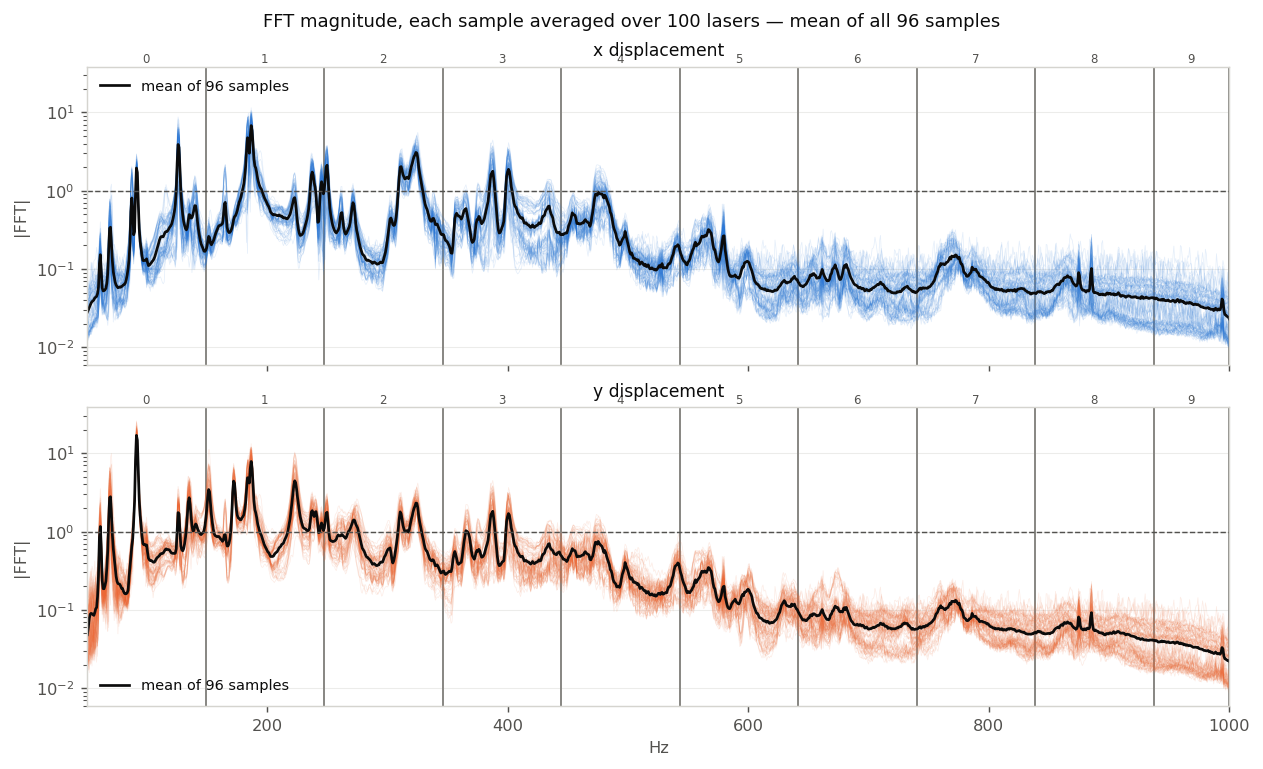

In [8]:
def plot_spectra(s=None, sample_id=None, position_id=None, speaker=None, log_mag=False,
                 title='', figsize=(9.6, 5.8)):
    """Per-sample spectra (faint) with the mean in bold, one panel per displacement channel.

    `s` is a (samples, lasers, bins, channels) array; defaults to the raw `spec`. Each sample is
    first averaged over its lasers. `sample_id` takes a scalar or a list. `log_mag` puts the
    y axis on a log scale and marks |FFT| = 1.
    """
    s = spec if s is None else s
    rows, label = _select(sample_id, position_id, speaker)
    per_sample = s[rows].mean(axis=1)                     # (k, bins, 2) mean over lasers
    fig, axes = plt.subplots(2, 1, figsize=figsize, sharex=True, sharey=True,
                             constrained_layout=True)
    for ax, c, color in zip(axes, range(2), [BLUE, ORANGE]):
        if len(rows) > 1:
            ax.plot(hz, per_sample[:, :, c].T, color=color, lw=0.4, alpha=0.12)
            ax.plot(hz, per_sample[:, :, c].mean(0), color=INK, lw=1.5,
                    label=f'mean of {len(rows)} samples')
        else:
            ax.plot(hz, per_sample[0, :, c], color=color, lw=0.9, label=label)
        ax.set_title(CHAN[c], fontsize=9.5, color=INK)
        ax.set_ylabel('|FFT|')
        if log_mag:
            ax.set_yscale('log')
            ax.axhline(1.0, color=MUTED, lw=0.8, ls='--')   # green above, red below
        ax.legend(frameon=False, fontsize=8)
        _band_lines(ax)
        ax.set_xlim(np.nanmin(hz), np.nanmax(hz))
    axes[-1].set_xlabel('Hz')
    fig.suptitle(f'{title or "FFT magnitude"}, each sample averaged over {s.shape[1]} lasers — {label}',
                 fontsize=10)
    plt.show()


plot_spectra(log_mag=True)

### 2. Frequency × laser heatmap

Colour is |FFT| magnitude, x = frequency, y = laser, one panel per channel. Defaults to the mean
over **all** samples, which is far cleaner than any single sample; pass `sample_id` or
`(position_id, speaker)` to inspect one.

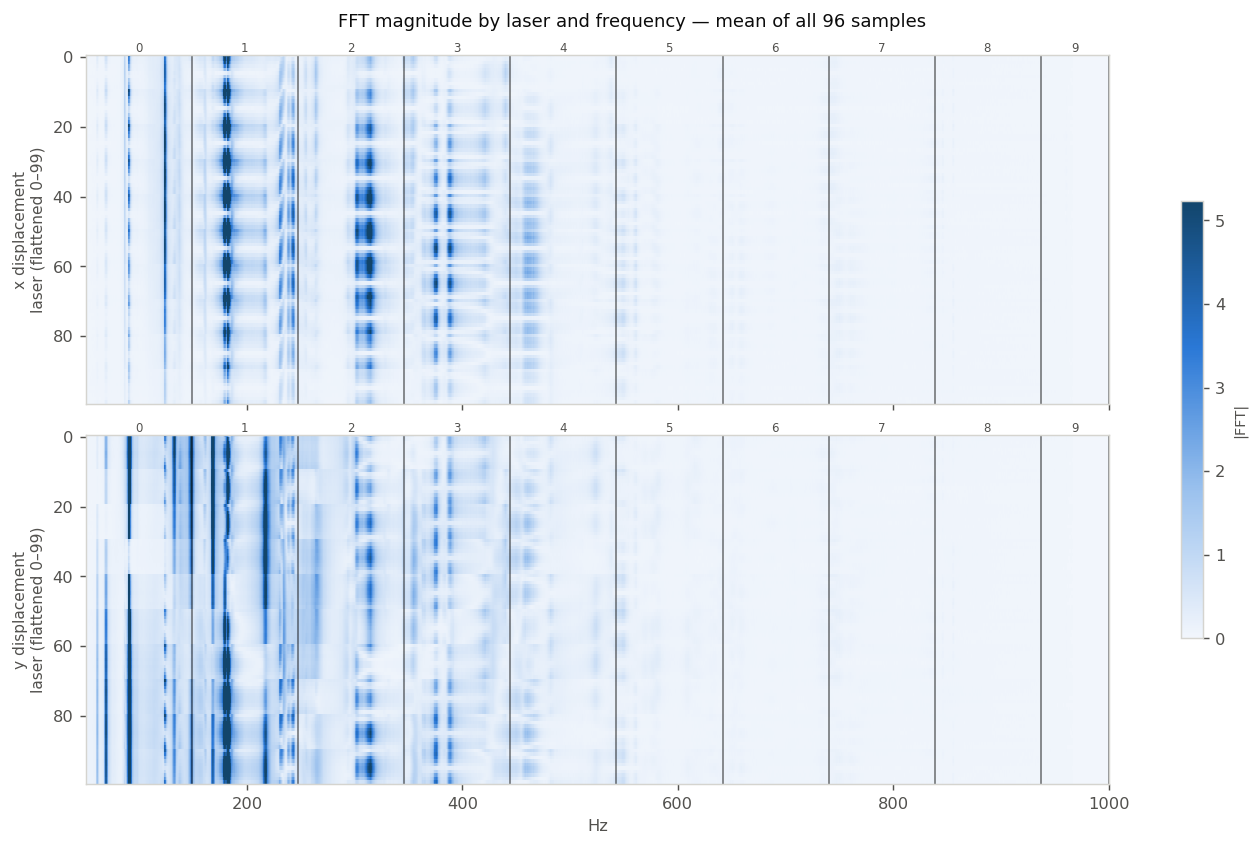

In [9]:
def plot_fft_heatmap(s=None, sample_id=None, position_id=None, speaker=None, log_mag=True,
                     clip=(2, 99.5), title='', figsize=(9.6, 6.4)):
    """|FFT| as freq x laser, one panel per displacement channel.

    `s` is a (samples, lasers, bins, channels) array; defaults to the raw `spec`. With no
    selector, averages over every sample (much less noisy than one sample).

    `log_mag` plots log10|FFT| on a diverging red/green scale centred on 0 — i.e. on |FFT| = 1,
    the reference of this std-normalized input. Green = above 1, red = below 1. The raw magnitude
    is never negative, so only in log space is a signed scale meaningful.
    """
    s = spec if s is None else s
    rows, label = _select(sample_id, position_id, speaker)
    v = s[rows].mean(0)                                   # (lasers, bins, 2)
    if log_mag:
        v = np.log10(v + 1e-3)
        lim = np.percentile(np.abs(v), clip[1])           # symmetric about 0 => midpoint is |FFT|=1
        kw = dict(cmap=DIV, vmin=-lim, vmax=lim)
        cbar = 'log10 |FFT|   (red < 1 < green)'
    else:
        kw = dict(cmap=SEQ, vmin=np.percentile(v, clip[0]), vmax=np.percentile(v, clip[1]))
        cbar = '|FFT|'

    fig, axes = plt.subplots(2, 1, figsize=figsize, sharex=True, constrained_layout=True)
    for ax, c in zip(axes, range(2)):
        im = ax.imshow(v[:, :, c], aspect='auto', extent=[np.nanmin(hz), np.nanmax(hz), 99.5, -0.5],
                       interpolation='nearest', **kw)
        ax.set_ylabel(f'{CHAN[c]}\nlaser (flattened 0–99)', fontsize=8.5)
        ax.grid(False)
        _band_lines(ax, color='#0b0b0b', alpha=0.45, lw=1.1)
    axes[-1].set_xlabel('Hz')
    cb = fig.colorbar(im, ax=axes, shrink=0.6)
    cb.set_label(cbar, fontsize=8)
    fig.suptitle(f'{title or "FFT magnitude"} by laser and frequency — {label}', fontsize=10)
    plt.show()


plot_fft_heatmap(log_mag=False)                                    # mean over all samples

Individual samples are much noisier than the average — worth a look to see how much the
mean is smoothing over.

In [10]:
# ids = meta.sample_id.tolist()

# plot_fft_heatmap(sample_id=ids[0])                    # one sample -- much noisier than the mean
# plot_spectra(sample_id=ids[:4], log_mag=True)         # a list of samples, log y axis
# plot_band_energy(sample_id=ids[0])                    # one sample

### 3. Mean energy per band — x and y separately

The same 11-band grid the attribution uses, so it lines up with §1.3.

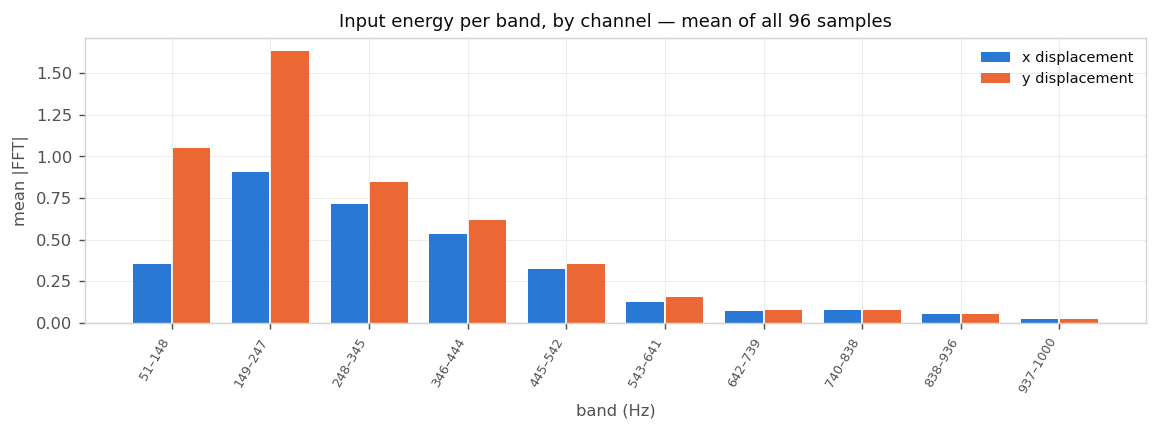

bands by raw signal energy (channel mean):
    149–247 Hz: 1.271   (x 0.909, y 1.633)
    248–345 Hz: 0.779   (x 0.711, y 0.847)
     51–148 Hz: 0.701   (x 0.353, y 1.048)
    346–444 Hz: 0.574   (x 0.532, y 0.617)
    445–542 Hz: 0.338   (x 0.323, y 0.352)
    543–641 Hz: 0.140   (x 0.123, y 0.157)
    740–838 Hz: 0.076   (x 0.078, y 0.074)
    642–739 Hz: 0.071   (x 0.068, y 0.074)
    838–936 Hz: 0.054   (x 0.054, y 0.053)
   937–1000 Hz: 0.022   (x 0.023, y 0.022)

resonance peaks: 92 Hz, 126 Hz, 187 Hz, 223 Hz, 324 Hz, 388 Hz


In [11]:
def plot_band_energy(s=None, sample_id=None, position_id=None, speaker=None, log_mag=False,
                     title='', figsize=(8.8, 3.2)):
    """Mean |FFT| per band, x and y side by side. Returns the (N_PATCHES, 2) band energies."""
    s = spec if s is None else s
    rows, label = _select(sample_id, position_id, speaker)
    sel = s[rows]
    be = sel.reshape(len(rows), sel.shape[1], N_PATCHES, PATCH_SIZE, 2).mean(axis=(0, 1, 3))   # (P, 2)
    x = np.arange(N_PATCHES)
    fig, ax = plt.subplots(figsize=figsize, constrained_layout=True)
    ax.bar(x - 0.2, be[:, 0], width=0.38, color=BLUE, label=CHAN[0])
    ax.bar(x + 0.2, be[:, 1], width=0.38, color=ORANGE, label=CHAN[1])
    band_ticks(ax, freq_lab)
    ax.set_xlabel(FREQ_UNIT); ax.set_ylabel('mean |FFT|')
    if log_mag: ax.set_yscale('log')
    ax.set_title(f'{title or "Input energy per band"}, by channel — {label}', fontsize=10, color=INK)
    ax.legend(frameon=False, fontsize=8)
    plt.show()
    return be


band_energy_xy = plot_band_energy()
band_energy = band_energy_xy.mean(1)     # channel-averaged, used by the §1.3 confound check

print('bands by raw signal energy (channel mean):')
for p in np.argsort(-band_energy):
    print(f'  {freq_lab[p]:>9s} Hz: {band_energy[p]:.3f}   '
          f'(x {band_energy_xy[p, 0]:.3f}, y {band_energy_xy[p, 1]:.3f})')

from scipy.signal import find_peaks
prof = spec.mean(axis=(0, 1, 3))
pk, _ = find_peaks(prof, height=prof.mean() + 1.5 * prof.std(), distance=40)
print('\nresonance peaks:', ', '.join(f'{hz[i]:.0f} Hz' for i in pk))

---
# §0.5 Per-band normalized magnitude

§0 showed a confound: the two bands the model relies on are also the two loudest, so importance
and raw energy are entangled (ρ ≈ 0.43 in §1.3). This section divides that energy out so the
*shape* within each band can be compared on equal footing.

**The operation.** From the tokenized input `X = (B, L, P, PS, C)` — batch, lasers, patches, patch
size, channels — take the mean over **lasers and patch-size**, keeping the patch axis:

```
denom  = X.mean(dim=(L, PS), keepdim=True)   ->  (B, 1, P, 1, 1)
X_norm = X / denom
```

Every band then has mean 1 within each sample, so no band is louder than another by construction.
What survives is *how* the energy is distributed across lasers and bins inside a band.

**Should the channel be pooled into the denominator?** Yes — and the tokenizer is what decides it.
`embed` is `nn.Linear(n_channels * patch_size, d_model)` fed by `x.reshape(B_L, P, -1)`
(`arch.py:198`), so one patch becomes a single 512-vector with x and y **interleaved**:

```
patch token = [ps0_x, ps0_y, ps1_x, ps1_y, ...]      # channel is the fastest axis
```

x and y are never separate anywhere in the model — one `nn.Linear` consumes both at once. So the
faithful simulation is **one scale factor per patch**, i.e. `(B, 1, P, 1, 1)`, pooling the channel.
Normalizing each channel separately would apply a per-channel rescaling the model has no way to
represent, and it also forces both channels to exactly 1.0 in every band, erasing the x/y
asymmetry. `per_channel=True` is available only for comparison.

In [12]:
def normalize_per_band(Xt, per_channel=False, eps=1e-8):
    """Divide each (sample, band) by its own mean over lasers and patch-size.

    Xt is (B, L, P, PS, C). Default pools the channel into the denominator -> (B,1,P,1,1), which
    matches how the model sees a patch (x and y interleaved in one token). per_channel=True gives
    (B,1,P,1,C) instead, which forces every band to exactly 1.0 in both channels.
    """
    dims = (1, 3) if per_channel else (1, 3, 4)
    return Xt / (Xt.mean(dim=dims, keepdim=True) + eps)


X_norm = normalize_per_band(X)
spec_norm = X_norm.reshape(X_norm.shape[0], X_norm.shape[1], -1, X_norm.shape[-1]).cpu().numpy()
print(f'{spec_norm.shape=}   mean {spec_norm.mean():.4f}, std {spec_norm.std():.4f}')

be_chk = spec_norm.reshape(spec_norm.shape[0], spec_norm.shape[1], N_PATCHES, PATCH_SIZE, 2).mean(axis=(0, 1, 3))
print('\nper-band mean after normalizing — flat overall, but the x/y split survives:')
for p in range(N_PATCHES):
    print(f'  {freq_lab[p]:>9s} Hz:  x {be_chk[p, 0]:.3f}   y {be_chk[p, 1]:.3f}")'.rstrip('")'))

spec_norm.shape=(96, 100, 1280, 2)   mean 1.0000, std 1.2600

per-band mean after normalizing — flat overall, but the x/y split survives:
     51–148 Hz:  x 0.508   y 1.492
    149–247 Hz:  x 0.715   y 1.285
    248–345 Hz:  x 0.911   y 1.089
    346–444 Hz:  x 0.911   y 1.089
    445–542 Hz:  x 0.957   y 1.043
    543–641 Hz:  x 0.878   y 1.122
    642–739 Hz:  x 0.954   y 1.046
    740–838 Hz:  x 1.023   y 0.977
    838–936 Hz:  x 0.992   y 1.008
   937–1000 Hz:  x 1.021   y 0.979


### The same three plots, on normalized magnitude

`spec` now points at the normalized data, so the §0 functions replot it unchanged.

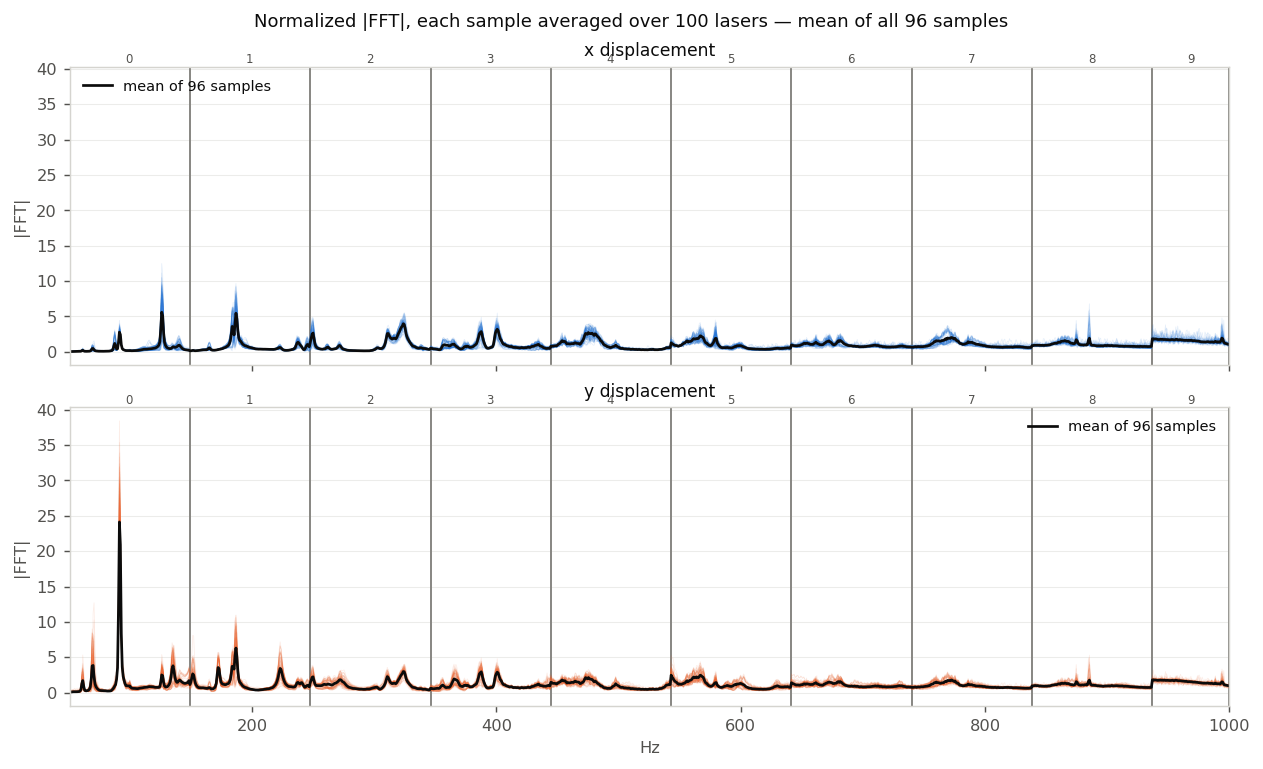

In [13]:
plot_spectra(spec_norm, log_mag=False, title='Normalized |FFT|')

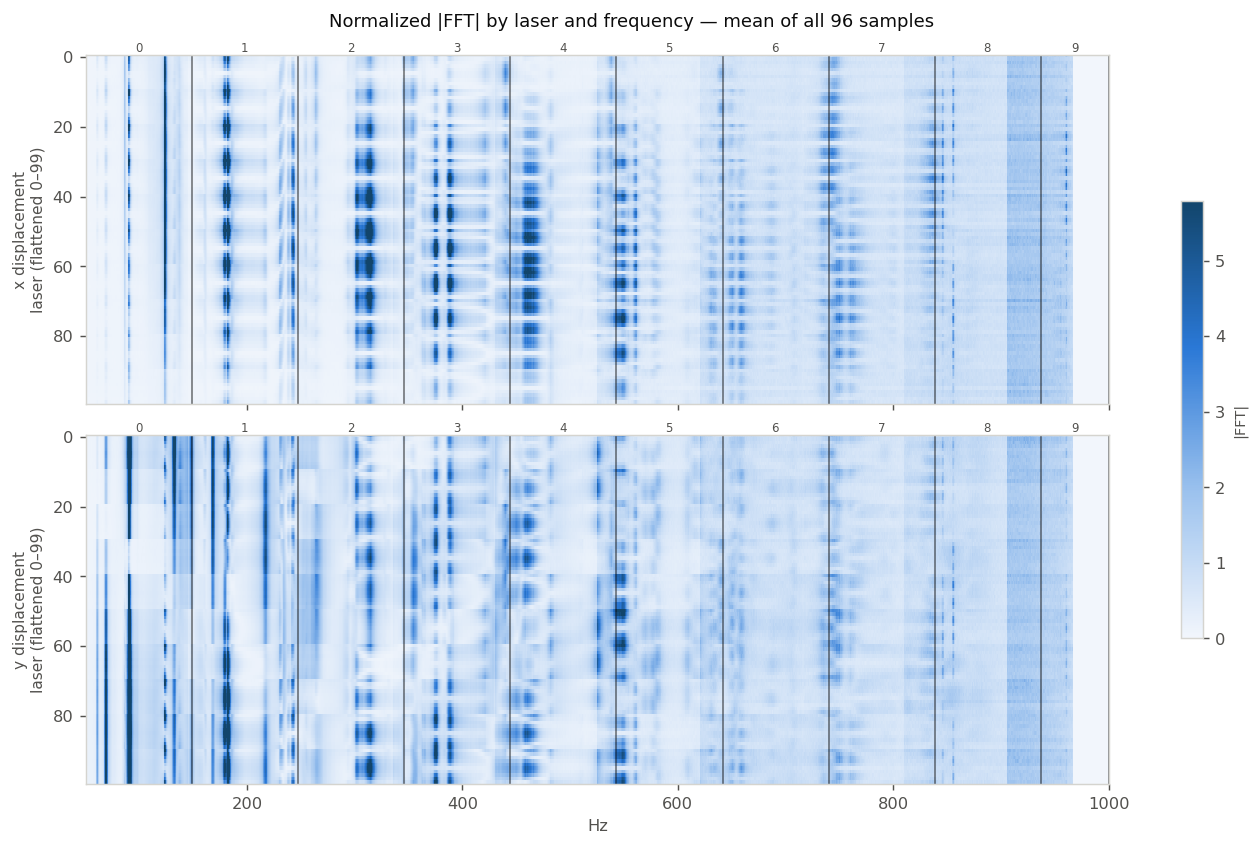

In [14]:
plot_fft_heatmap(spec_norm, log_mag=False, title='Normalized |FFT|')

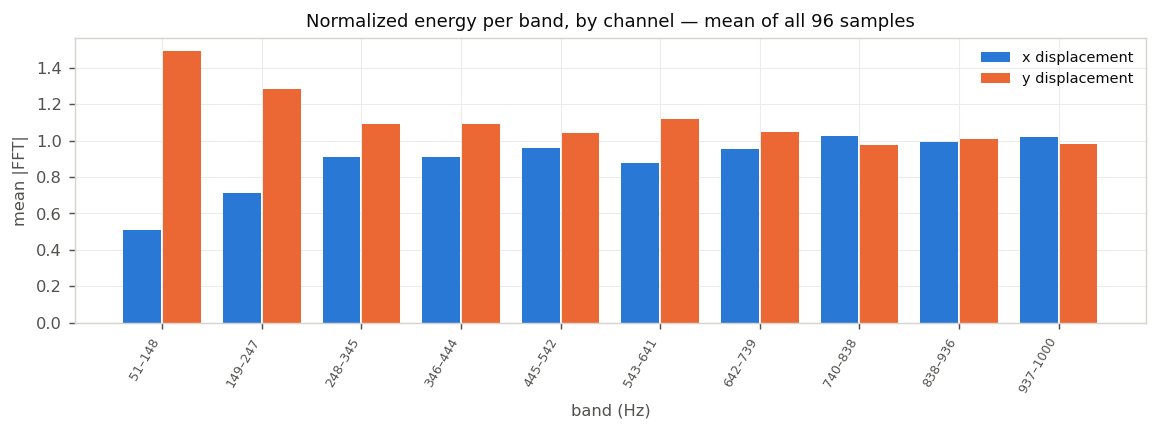

In [15]:
_ = plot_band_energy(spec_norm, title='Normalized energy per band')

**What normalizing reveals.** Band-level loudness dominated the raw view; with it removed, what
is left is *which lasers* carry each band — and that turns out to be strongly laser-dependent.

- In the resonant bands (1 and 4), the **y channel concentrates sharply on particular lasers**
  (green stripes) while the **x channel is broadly attenuated** there. The energy in those bands
  is not spread evenly over the grid.
- The x/y asymmetry is itself largest exactly in the bands that matter: 0.78 / 1.22 in bands 1 and
  4, versus ~0.99 / 1.01 in the quiet bands 7–10. So the resonances are substantially a
  **y-displacement** phenomenon.
- Bands 7–10 stay flat and near-neutral even after normalizing — there is no internal structure
  hiding under their low energy, consistent with ablation finding them worthless.

This is the input-side counterpart to §1.3's finding that importance is not simply loudness.

---
# §1 Frequencies

11 bands of 256 FFT bins each, spanning 50–958 Hz.

## 1.1 Attention matrix — all bands × all bands

Row = **query** (who attends), column = **key** (what is attended to). Each row sums to 1. Orange
lines mark the cls token, so row 0 is the cls row plotted in §1.2.

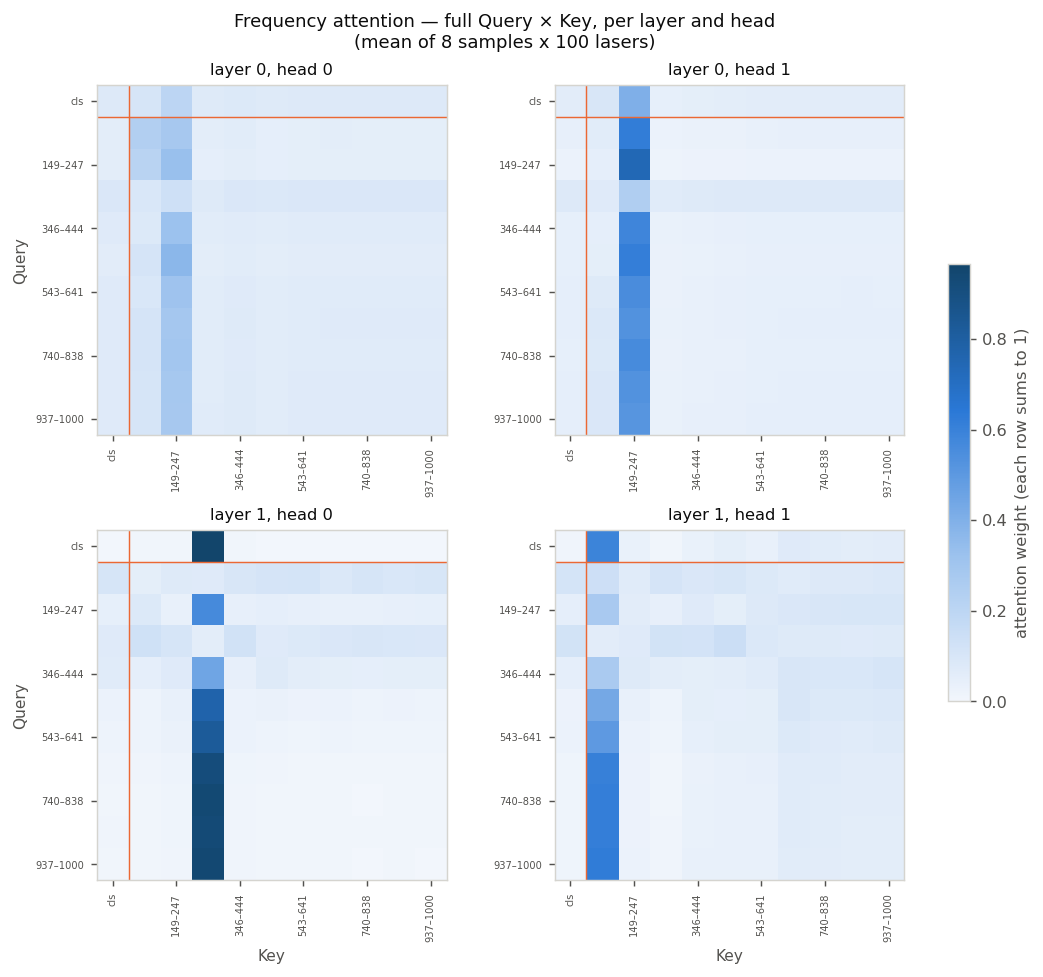

In [16]:
vmax_freq = attn_matrix_grid(
    full_freq, ['cls'] + freq_lab,
    f'Frequency attention — full Query × Key, per layer and head\n(mean of {N_FULL} samples x {N_LASERS} lasers)',
    figsize=(8.2, 7.4))

**Vertical stripes are the story.** *Every* query band attends to the same key band, not
just cls — so band selection is a property of the whole layer, not an artifact of reading row 0.
Layer 1 head 0 routes almost everything to **380–463 Hz**, head 1 to **133–215 Hz**. Layer 0 is a
weaker version of the same, already leaning on 133–215 Hz.

The two layer-1 heads specialize almost disjointly, so **averaging over heads destroys this** —
read frequency attention per-head.

## 1.2 CLS attention — cls as query, each band as key

The cls row matters because `FreqEncoder` returns only `output[:, 0, :]` (`arch.py:205`): cls is
the sole path from a laser's spectrum into the rest of the model. Same colour scale as §1.1.

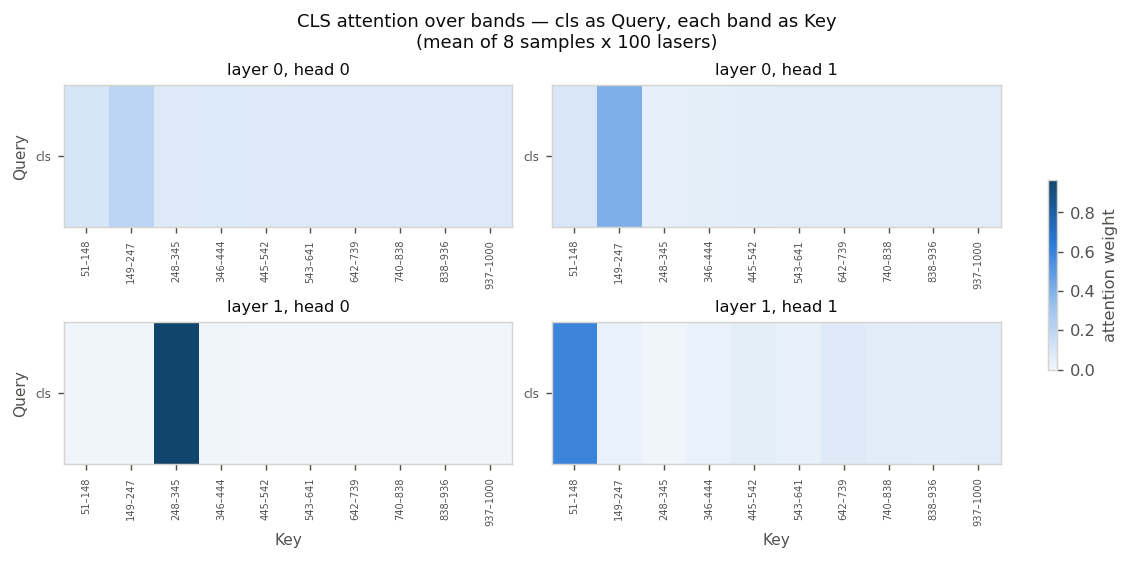

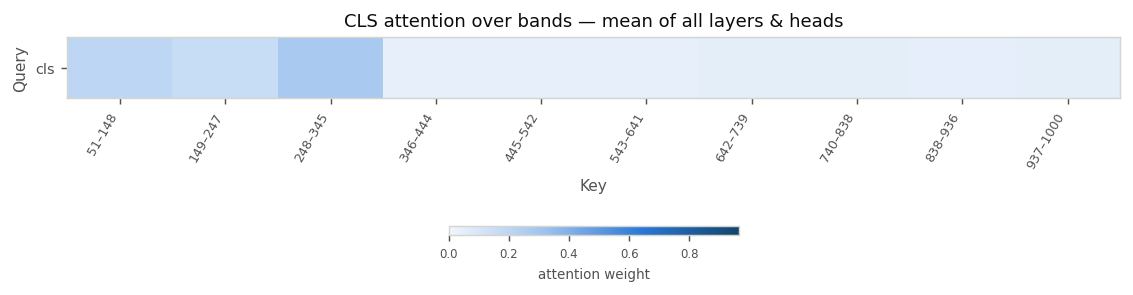

per-(layer,head) rank agreement with the mean:
  layer 0 head 0: ρ = +0.188
  layer 0 head 1: ρ = +0.321
  layer 1 head 0: ρ = +0.273
  layer 1 head 1: ρ = +0.200


In [17]:
strip_grid(cls_freq, freq_lab,
           f'CLS attention over bands — cls as Query, each band as Key\n(mean of {N_FULL} samples x {N_LASERS} lasers)',
           'attention weight', figsize=(8.6, 4.2), vmax=vmax_freq)

strip(af, freq_lab, 'CLS attention over bands — mean of all layers & heads',
      'attention weight', vmin=0, vmax=vmax_freq, figsize=(8.6, 2.3))

print('per-(layer,head) rank agreement with the mean:')
for i in range(nl):
    for h in range(nh):
        print(f'  layer {i} head {h}: ρ = {spearmanr(cls_freq[i, h], af).statistic:+.3f}')

## 1.3 Ablation — Δ BCE from zeroing each band

Green = removing it **hurt** (the band mattered). Red = removing it slightly **helped**.

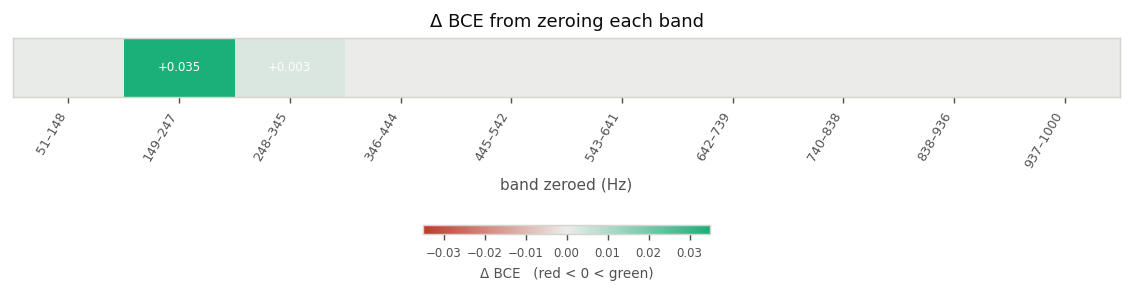

    149–247 Hz   Δ BCE +0.03501   BCE 0.0186 -> 0.0536 (+189%)
    248–345 Hz   Δ BCE +0.00282   BCE 0.0186 -> 0.0214 (+15%)
     51–148 Hz   Δ BCE +0.00036   BCE 0.0186 -> 0.0189 (+2%)
    642–739 Hz   Δ BCE -0.00000   BCE 0.0186 -> 0.0186 (-0%)


In [18]:
ablate_freq = ablate_freq_patches(model, X, y, baseline)
strip(ablate_freq, freq_lab, 'Δ BCE from zeroing each band', 'Δ BCE   (red < 0 < green)',
      diverging=True, figsize=(8.6, 2.3), annot=np.argsort(-ablate_freq)[:2],
      xlabel='band zeroed (Hz)', ylabel='')

for p in np.argsort(-ablate_freq)[:4]:
    print(f'  {freq_lab[p]:>9s} Hz   Δ BCE {ablate_freq[p]:+.5f}   '
          f'BCE {baseline:.4f} -> {baseline + ablate_freq[p]:.4f} '
          f'({100 * ablate_freq[p] / baseline:+.0f}%)')

### Is this just where the signal is loudest?

§0 showed the two loudest bands are also the two most important, so importance and input energy are
confounded. This separates them.

ρ(band energy, ablation Δ BCE) = 0.648


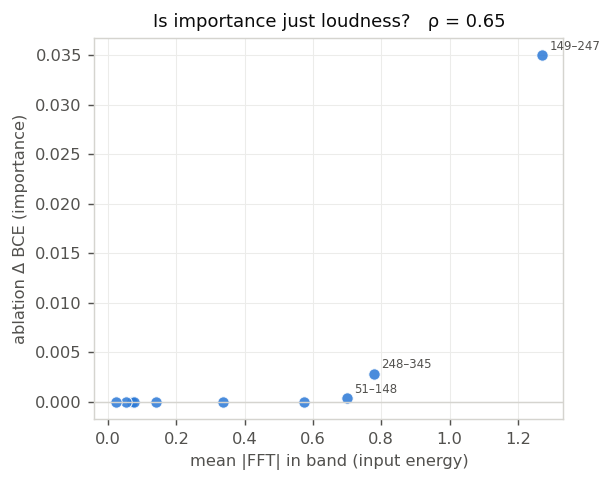


loudest 3 : ['149–247', '248–345', '51–148']
top-3 abl : ['149–247', '248–345', '51–148']

445–542 Hz is the 5th loudest band but ranks 9th of 10 by ablation (Δ BCE -0.00002) —
so the model is not simply following energy.


In [19]:
# Is importance just energy? §0 showed the two loudest bands are also the two most important.
rho_e = spearmanr(band_energy, ablate_freq).statistic
print(f'ρ(band energy, ablation Δ BCE) = {rho_e:.3f}')

fig, ax = plt.subplots(figsize=(4.6, 3.6), constrained_layout=True)
ax.scatter(band_energy, ablate_freq, s=40, color=BLUE, alpha=0.85, edgecolor='white', linewidth=0.6)
# labelling every band overlaps into mush once N_PATCHES is large; the interesting points are
# the extremes of either axis, so label those and leave the rest as bare dots.
mark = set(np.argsort(-ablate_freq)[:3]) | set(np.argsort(-band_energy)[:3])
for p in sorted(mark):
    ax.annotate(freq_lab[p], (band_energy[p], ablate_freq[p]), textcoords='offset points',
                xytext=(4, 3), fontsize=6.5, color=MUTED)
ax.axhline(0, color='#d5d4cf', lw=0.8)
ax.set_xlabel('mean |FFT| in band (input energy)'); ax.set_ylabel('ablation Δ BCE (importance)')
ax.set_title(f'Is importance just loudness?   ρ = {rho_e:.2f}', fontsize=10, color=INK)
plt.show()

loud = np.argsort(-band_energy)
imp = np.argsort(-ablate_freq)
print(f'\nloudest 3 : {[freq_lab[p] for p in loud[:3]]}')
print(f'top-3 abl : {[freq_lab[p] for p in imp[:3]]}')
# the clearest counterexample: whichever loud band the model cares least about
gap = max(loud[:5], key=lambda p: list(imp).index(p))
print(f'\n{freq_lab[gap]} Hz is the {list(loud).index(gap) + 1}th loudest band but ranks '
      f'{list(imp).index(gap) + 1}th of {N_PATCHES} by ablation (Δ BCE {ablate_freq[gap]:+.5f}) —')
print('so the model is not simply following energy.')

## 1.4 Agreement — cls attention vs ablation

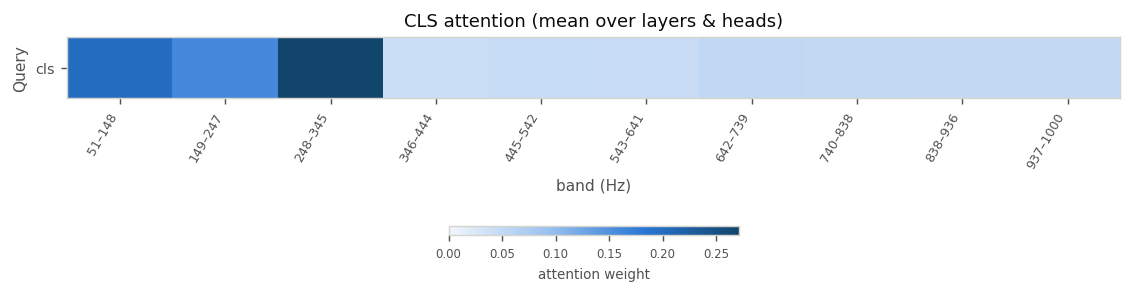

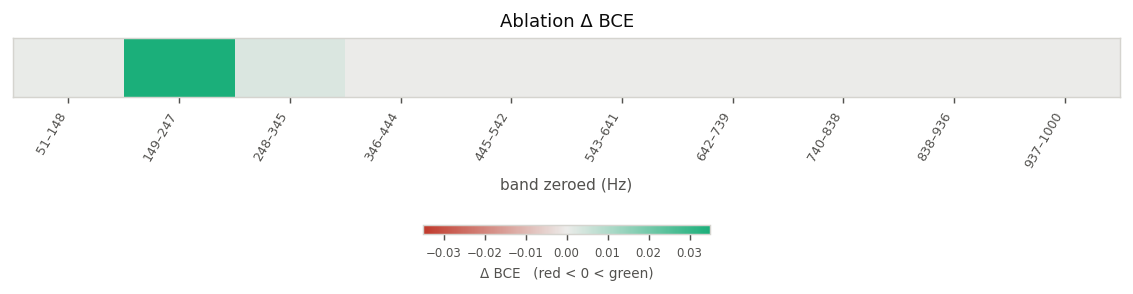

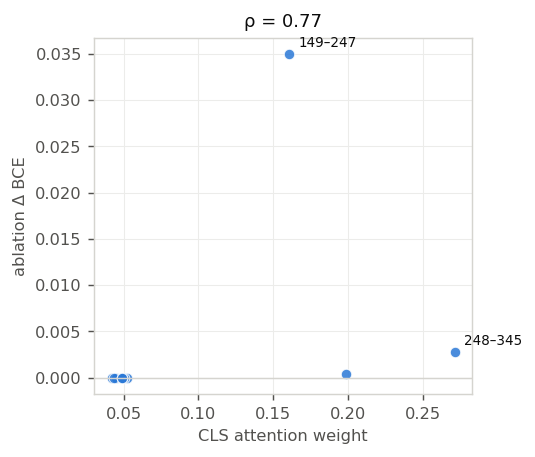

Spearman ρ(cls attention, ablation) = 0.770
  top-3 by ablation : ['149–247', '248–345', '51–148']
  top-3 by attention: ['248–345', '51–148', '149–247']


In [20]:
strip(af, freq_lab, 'CLS attention (mean over layers & heads)', 'attention weight',
      vmin=0, vmax=af.max(), figsize=(8.6, 2.3), xlabel='band (Hz)')
strip(ablate_freq, freq_lab, 'Ablation Δ BCE', 'Δ BCE   (red < 0 < green)',
      diverging=True, figsize=(8.6, 2.3), xlabel='band zeroed (Hz)', ylabel='')

fig, ax = plt.subplots(figsize=(4.0, 3.4), constrained_layout=True)
ax.scatter(af, ablate_freq, s=34, color=BLUE, alpha=0.85, edgecolor='white', linewidth=0.6)
for p in np.argsort(-ablate_freq)[:2]:
    ax.annotate(freq_lab[p], (af[p], ablate_freq[p]), textcoords='offset points',
                xytext=(5, 4), fontsize=7.5, color=INK)
ax.axhline(0, color='#d5d4cf', lw=0.8)
ax.set_xlabel('CLS attention weight'); ax.set_ylabel('ablation Δ BCE')
ax.set_title(f'ρ = {spearmanr(af, ablate_freq).statistic:.2f}', fontsize=10, color=INK)
plt.show()

print(f'Spearman ρ(cls attention, ablation) = {spearmanr(af, ablate_freq).statistic:.3f}')
print('  top-3 by ablation :', [freq_lab[p] for p in np.argsort(-ablate_freq)[:3]])
print('  top-3 by attention:', [freq_lab[p] for p in np.argsort(-af)[:3]])

## 1.5 Top-k — keep only the k best bands

Two rankings, one curve each. If attention were a good importance measure its curve would sit on
top of ablation's.

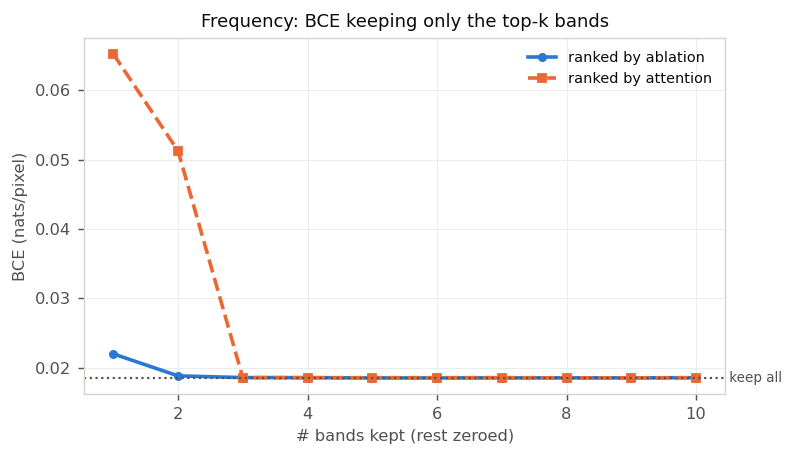

  k   by ablation   by attention
  1        0.0220         0.0652
  2        0.0188         0.0513
  3        0.0186         0.0186
  4        0.0186         0.0186
  5        0.0185         0.0186
  6        0.0185         0.0186
  7        0.0185         0.0186
  8        0.0185         0.0185
  9        0.0185         0.0185
 10        0.0186         0.0186


In [21]:
fk_attn, fk_abl = topk_curve(model, X, y, af, ablate_freq, 'freq', range(1, N_PATCHES + 1), baseline,
                             'Frequency: BCE keeping only the top-k bands')
print(f'{"k":>3} {"by ablation":>13} {"by attention":>14}')
for k in fk_abl:
    print(f'{k:>3} {fk_abl[k]:>13.4f} {fk_attn[k]:>14.4f}')

---
# §2 Lasers

100 lasers on a 10×10 grid. Laser `i` sits at row `i//10`, col `i%10`, matching the 2D RoPE grid
(`arch.py:220`). The attention matrix needs them flattened; the 1-D results are shown **both**
flattened and reshaped to the physical grid.

## 2.1 Attention matrix — all lasers × all lasers

Same convention as §1.1, with lasers flattened to a single axis (index 0 = cls).

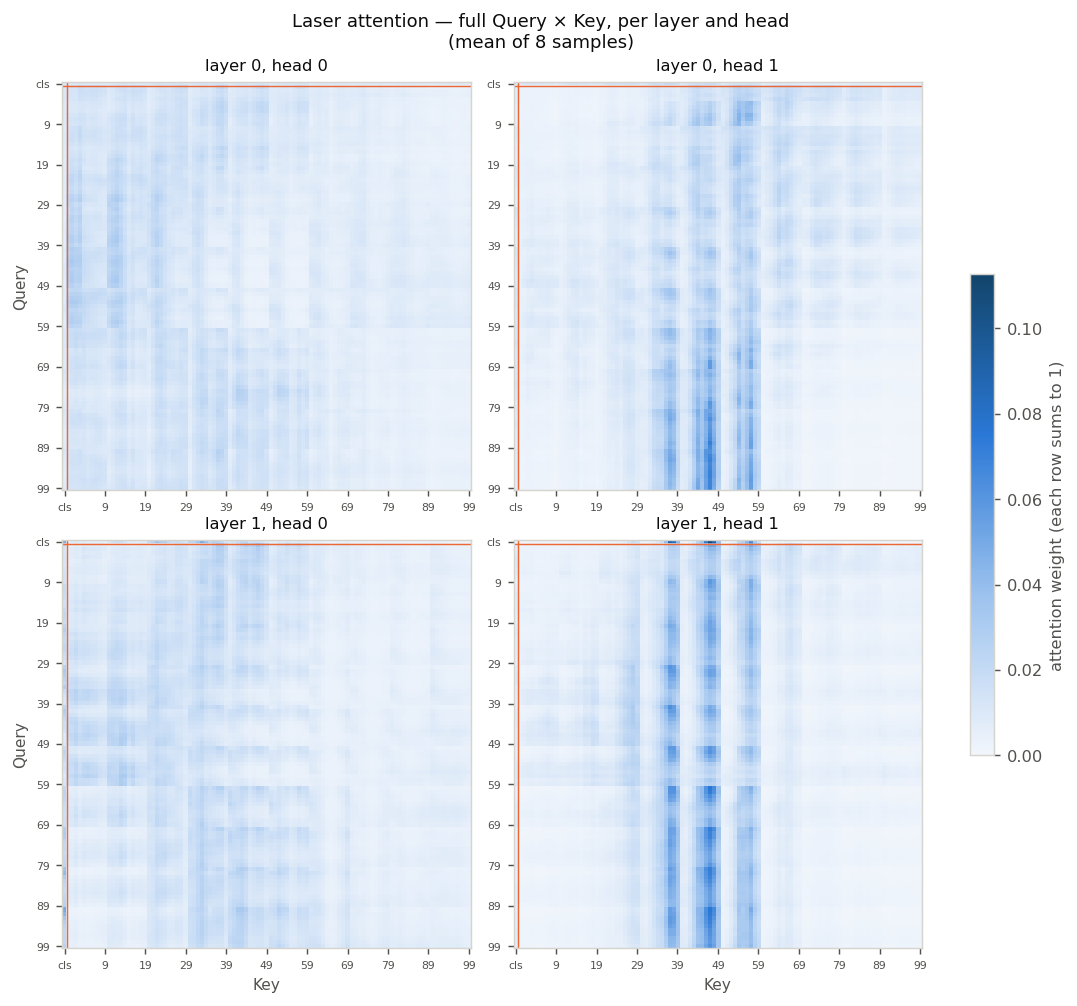

across-query variation, as a multiple of the mean weight (0 = every query identical):
  layer 0 head 0: 0.27x
  layer 0 head 1: 0.41x
  layer 1 head 0: 0.31x
  layer 1 head 1: 0.33x


In [22]:
vmax_laser = attn_matrix_grid(
    full_laser, ['cls'] + [str(i) for i in range(N_LASERS)],
    f'Laser attention — full Query × Key, per layer and head\n(mean of {N_FULL} samples)',
    figsize=(8.2, 7.6), every=10, rot=0, fs=6)

# does the choice of keys depend on which query it is?
print('across-query variation, as a multiple of the mean weight (0 = every query identical):')
for i in range(nl):
    for h in range(nh):
        M = full_laser[i, h][1:, 1:]
        print(f'  layer {i} head {h}: {M.std(0).mean() / M.mean():.2f}x')

Same vertical striping — a few lasers are read by everyone — but **far weaker than on the
frequency axis**. Peak weight is ~0.035 against a uniform baseline of 1/101 ≈ 0.0099 (~3.5×
uniform), where the layer-1 frequency heads reach 0.85 (~10× uniform).

Across-query variation is only ~0.2–0.3× the mean weight, i.e. which laser you attend *from*
barely changes what you attend *to*.

## 2.2 CLS attention — cls as query, each laser as key

Flattened first, then the same values on the physical 10×10 grid.

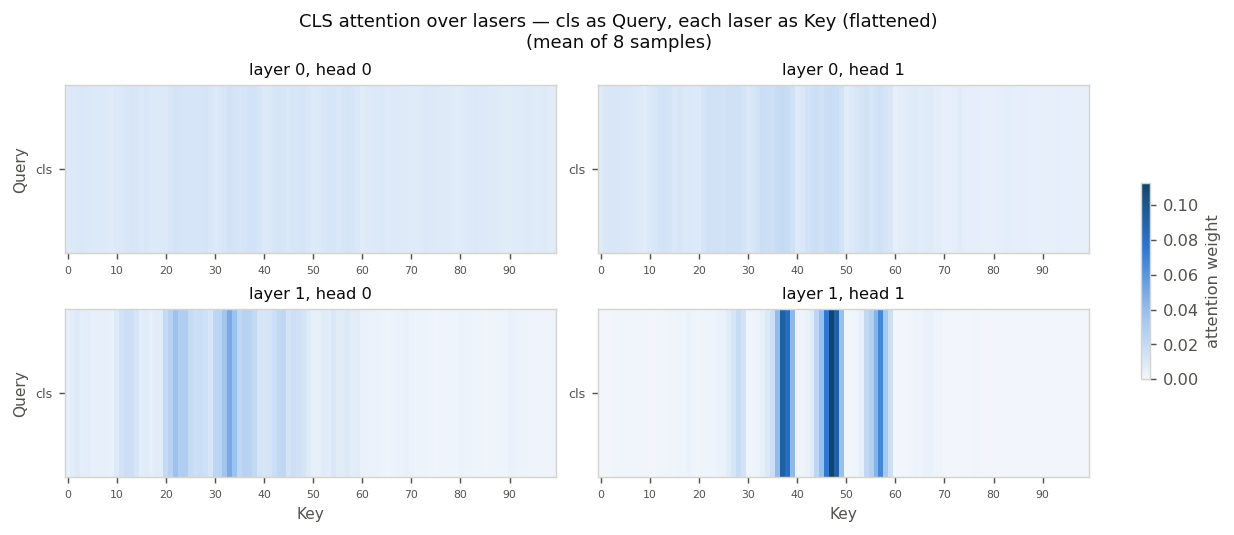

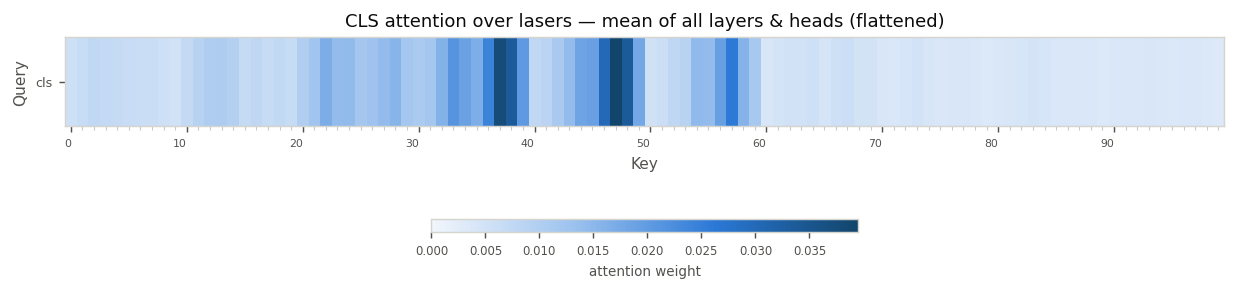

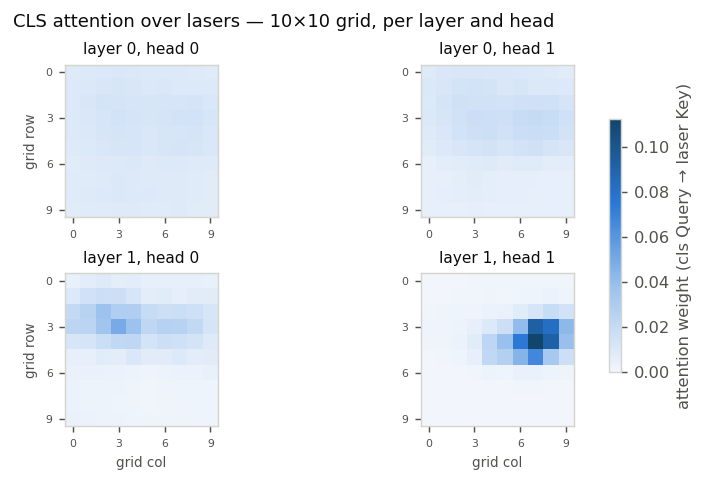

per-(layer,head) rank agreement with the mean:
  layer 0 head 0: ρ = +0.925
  layer 0 head 1: ρ = +0.977
  layer 1 head 0: ρ = +0.898
  layer 1 head 1: ρ = +0.899


In [23]:
laser_tick = [str(i) if i % 10 == 0 else '' for i in range(N_LASERS)]
strip_grid(cls_laser, laser_tick,
           f'CLS attention over lasers — cls as Query, each laser as Key (flattened)\n(mean of {N_FULL} samples)',
           'attention weight', figsize=(9.4, 4.0), vmax=cls_laser.max(), rot=0, fs=6)

strip(al, laser_tick,
      'CLS attention over lasers — mean of all layers & heads (flattened)',
      'attention weight', vmin=0, vmax=al.max(), figsize=(9.4, 2.3), rot=0, fs=6)

fig, axes = plt.subplots(nl, nh, figsize=(6.4, 3.6), constrained_layout=True, squeeze=False)
for i in range(nl):
    for h in range(nh):
        ax = axes[i, h]
        im = ax.imshow(cls_laser[i, h].reshape(GRID_H, GRID_W), cmap=SEQ, vmin=0, vmax=cls_laser.max())
        ax.set_title(f'layer {i}, head {h}', fontsize=8.5, color=INK); ax.grid(False)
        ax.set_xticks(range(0, 10, 3)); ax.set_yticks(range(0, 10, 3)); ax.tick_params(labelsize=6)
        if i == nl - 1: ax.set_xlabel('grid col', fontsize=7.5)
        if h == 0: ax.set_ylabel('grid row', fontsize=7.5)
fig.colorbar(im, ax=axes, shrink=0.7, label='attention weight (cls Query → laser Key)')
fig.suptitle('CLS attention over lasers — 10×10 grid, per layer and head', fontsize=10)
plt.show()

print('per-(layer,head) rank agreement with the mean:')
for i in range(nl):
    for h in range(nh):
        print(f'  layer {i} head {h}: ρ = {spearmanr(cls_laser[i, h], al).statistic:+.3f}')

## 2.3 Ablation — Δ BCE from zeroing each laser

Green = removing it hurt, red = removing it helped. Flattened, then on the grid.

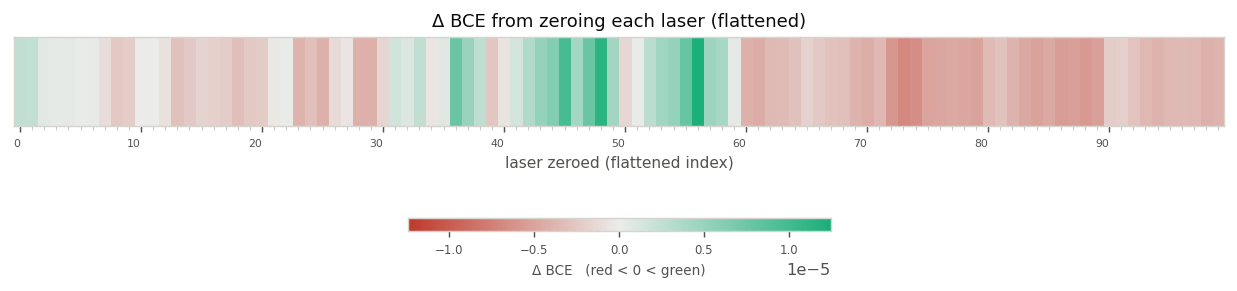

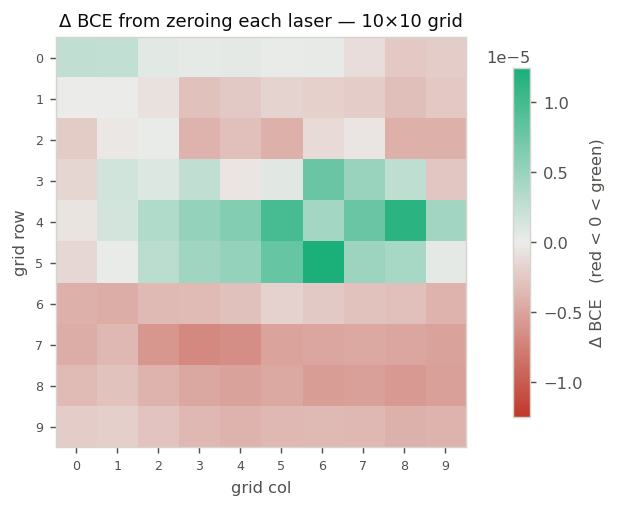

top-10 lasers by ablation: [56 48 45 55 47 36 44 54 43 37]
largest single-laser Δ BCE = 0.000012 (0.1% of baseline)


In [24]:
ablate_laser = ablate_lasers(model, X, y, baseline)
strip(ablate_laser, [str(i) if i % 10 == 0 else '' for i in range(N_LASERS)],
      'Δ BCE from zeroing each laser (flattened)', 'Δ BCE   (red < 0 < green)',
      diverging=True, figsize=(9.4, 2.3), rot=0, fs=6,
      xlabel='laser zeroed (flattened index)', ylabel='')

fig, ax = plt.subplots(figsize=(4.6, 3.8), constrained_layout=True)
lim = np.abs(ablate_laser).max()
im = ax.imshow(ablate_laser.reshape(GRID_H, GRID_W), cmap=DIV, vmin=-lim, vmax=lim)
ax.set_xticks(range(10)); ax.set_yticks(range(10)); ax.tick_params(labelsize=7); ax.grid(False)
ax.set_xlabel('grid col'); ax.set_ylabel('grid row')
ax.set_title('Δ BCE from zeroing each laser — 10×10 grid', fontsize=10, color=INK)
fig.colorbar(im, ax=ax, shrink=0.85, label='Δ BCE   (red < 0 < green)')
plt.show()

print('top-10 lasers by ablation:', np.argsort(-ablate_laser)[:10])
print(f'largest single-laser Δ BCE = {ablate_laser.max():.6f} '
      f'({100 * ablate_laser.max() / baseline:.1f}% of baseline)')

## 2.4 Agreement — cls attention vs ablation

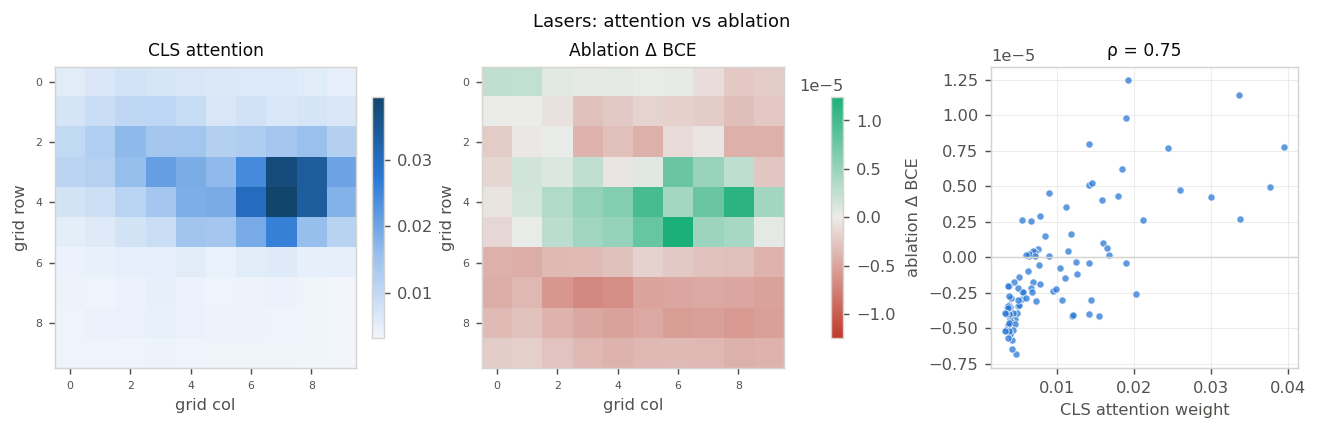

Spearman ρ(cls attention, ablation) = 0.745
  top-10 by ablation : [56 48 45 55 47 36 44 54 43 37]
  top-10 by attention: [47 37 38 48 46 57 36 33 39 56]


In [25]:
fig, axes = plt.subplots(1, 3, figsize=(10.0, 3.2), constrained_layout=True)
im = axes[0].imshow(al.reshape(GRID_H, GRID_W), cmap=SEQ)
axes[0].set_title('CLS attention', fontsize=9.5, color=INK)
fig.colorbar(im, ax=axes[0], shrink=0.8)
lim = np.abs(ablate_laser).max()
im = axes[1].imshow(ablate_laser.reshape(GRID_H, GRID_W), cmap=DIV, vmin=-lim, vmax=lim)
axes[1].set_title('Ablation Δ BCE', fontsize=9.5, color=INK)
fig.colorbar(im, ax=axes[1], shrink=0.8)
for ax in axes[:2]:
    ax.grid(False); ax.tick_params(labelsize=6)
    ax.set_xlabel('grid col'); ax.set_ylabel('grid row')
axes[2].scatter(al, ablate_laser, s=16, color=BLUE, alpha=0.75, edgecolor='white', linewidth=0.5)
axes[2].axhline(0, color='#d5d4cf', lw=0.8)
axes[2].set_xlabel('CLS attention weight'); axes[2].set_ylabel('ablation Δ BCE')
axes[2].set_title(f'ρ = {spearmanr(al, ablate_laser).statistic:.2f}', fontsize=9.5, color=INK)
fig.suptitle('Lasers: attention vs ablation', fontsize=10)
plt.show()

print(f'Spearman ρ(cls attention, ablation) = {spearmanr(al, ablate_laser).statistic:.3f}')
print('  top-10 by ablation :', np.argsort(-ablate_laser)[:10])
print('  top-10 by attention:', np.argsort(-al)[:10])

## 2.5 Top-k — keep only the k best lasers

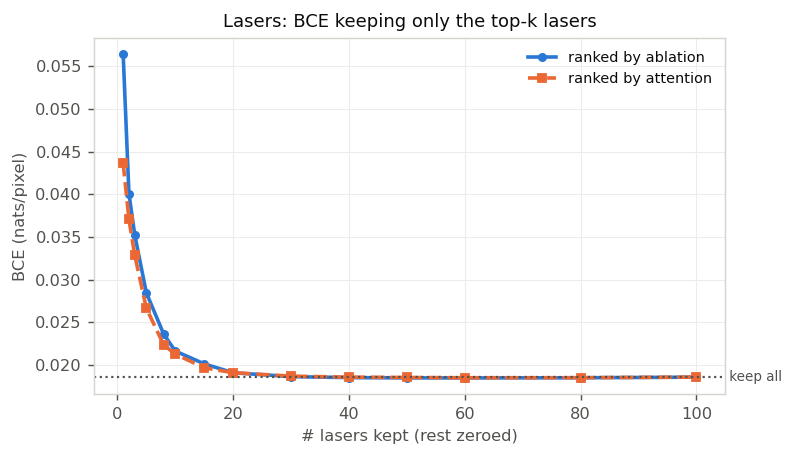

   k   by ablation   by attention
   1        0.0565         0.0437
   2        0.0401         0.0370
   3        0.0352         0.0329
   5        0.0285         0.0266
   8        0.0236         0.0223
  10        0.0216         0.0213
  15        0.0201         0.0196
  20        0.0191         0.0191
  30        0.0186         0.0187
  40        0.0185         0.0186
  50        0.0185         0.0185
  60        0.0185         0.0185
  80        0.0185         0.0185
 100        0.0186         0.0186


In [26]:
ks = [k for k in [1, 2, 3, 5, 8, 10, 15, 20, 30, 40, 50, 60, 80, 100] if k <= N_LASERS]
if ks[-1] != N_LASERS: ks.append(N_LASERS)
lk_attn, lk_abl = topk_curve(model, X, y, al, ablate_laser, 'laser', ks, baseline,
                             'Lasers: BCE keeping only the top-k lasers')
print(f'{"k":>4} {"by ablation":>13} {"by attention":>14}')
for k in lk_abl:
    print(f'{k:>4} {lk_abl[k]:>13.4f} {lk_attn[k]:>14.4f}')

---
# §3 Joint laser × frequency

The question attention structurally cannot answer: freq attention runs per-laser and never sees
other lasers, while laser attention runs after frequency has been collapsed into one vector. No
attention map anywhere is jointly indexed by (laser, band) — only ablation is.

joint.shape=(100, 10)   (lasers in flattened order 0-99, bands 50-958 Hz)


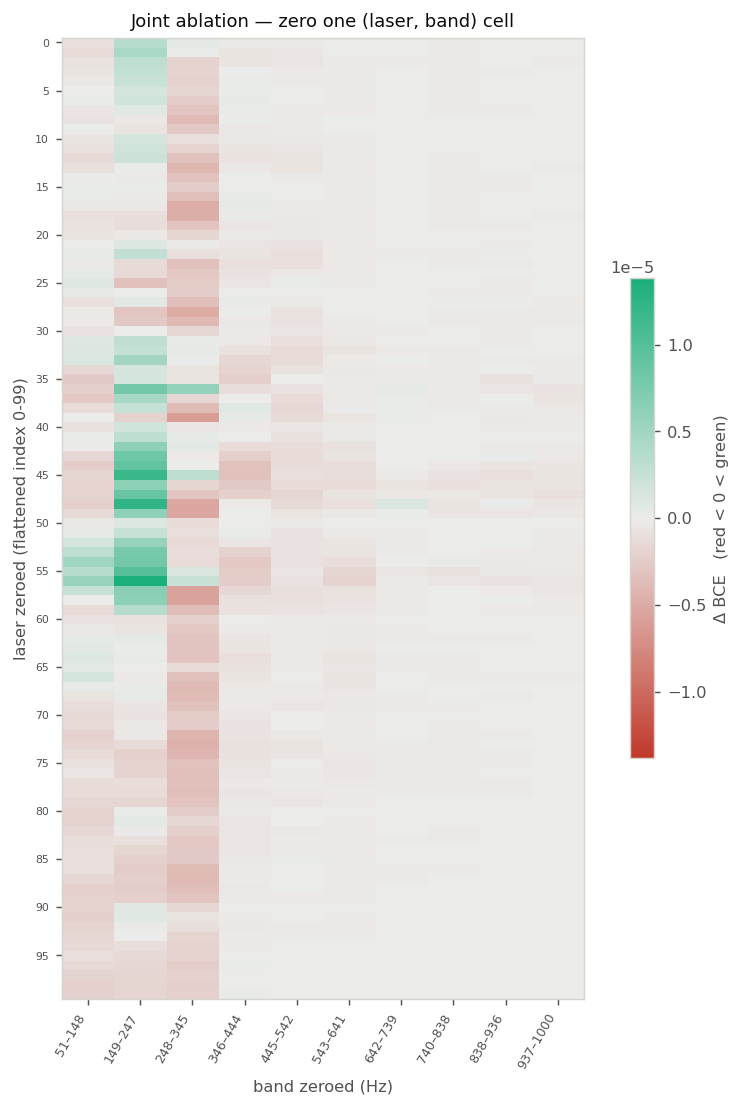

In [27]:
# every laser x every band, in natural (unsorted) order: N_LASERS x N_PATCHES forwards
joint = ablate_laser_freq(model, X, y, baseline=baseline)   # (N_LASERS, N_PATCHES)
print(f'{joint.shape=}   (lasers in flattened order 0-99, bands 50-958 Hz)')

jlim = np.abs(joint).max()
fig, ax = plt.subplots(figsize=(min(5.0 + 0.06 * N_PATCHES, 12.0), 8.4), constrained_layout=True)
im = ax.imshow(joint, cmap=DIV, vmin=-jlim, vmax=jlim, aspect='auto')
band_ticks(ax, freq_lab)
ax.set_yticks(range(0, N_LASERS, 5)); ax.tick_params(axis='y', labelsize=6)
ax.set_xlabel('band zeroed (Hz)'); ax.set_ylabel('laser zeroed (flattened index 0-99)')
ax.grid(False)
fig.colorbar(im, ax=ax, shrink=0.5, label='Δ BCE   (red < 0 < green)')
ax.set_title('Joint ablation — zero one (laser, band) cell', fontsize=10, color=INK)
plt.show()

### Same data as a 10×10 laser grid per band

The heatmap above is hard to read spatially because lasers are flattened. Here each panel is one
band, laid out on the physical grid, with a shared colour scale across panels.

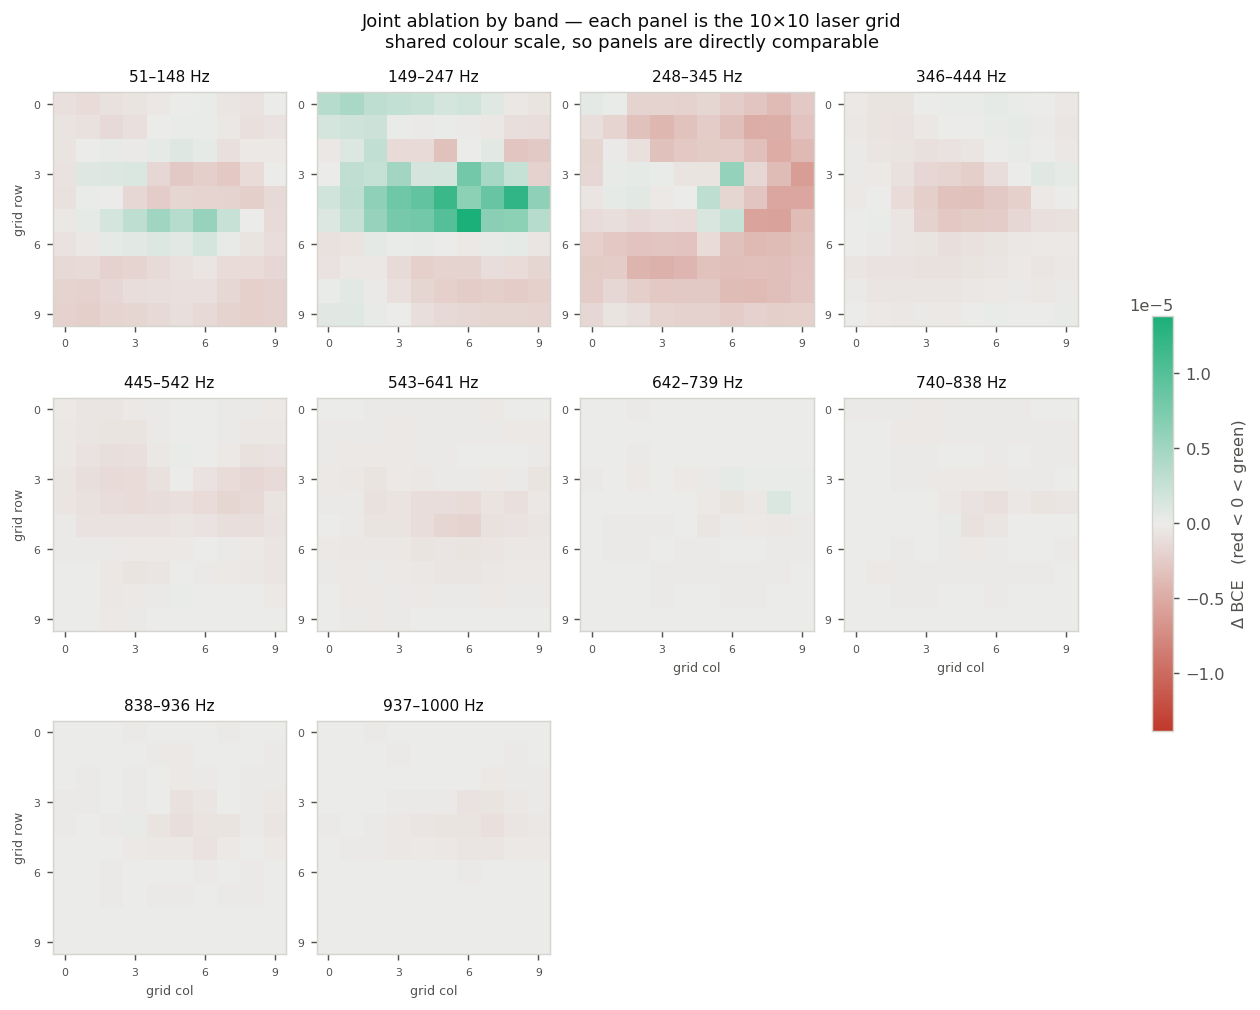

largest single cell Δ BCE = 0.000014
largest whole-band       = 0.03501  (2530x bigger)
largest whole-laser      = 0.000012  (0.9x bigger)

bands with the most spread across lasers:
    149–247 Hz: std 3.60e-06, max +1.38e-05 at laser 56
    248–345 Hz: std 1.85e-06, max +5.66e-06 at laser 36
     51–148 Hz: std 1.43e-06, max +5.52e-06 at laser 56
    346–444 Hz: std 7.94e-07, max +7.86e-07 at laser 38


In [28]:
# same data, re-laid out: one laser grid per band, so spatial structure is visible.
# 93 panels would be postage stamps, so show the most important bands (by |Δ BCE|) instead.
MAX_PANELS = 12
show = (list(range(N_PATCHES)) if N_PATCHES <= MAX_PANELS
        else sorted(np.argsort(-np.abs(joint).max(0))[:MAX_PANELS]))
ncol = 4; nrow = int(np.ceil(len(show) / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(9.6, 2.0 + 1.9 * nrow), constrained_layout=True,
                         squeeze=False)
for k, ax in enumerate(axes.ravel()):
    if k >= len(show):
        ax.axis('off'); continue
    p = show[k]
    im = ax.imshow(joint[:, p].reshape(GRID_H, GRID_W), cmap=DIV, vmin=-jlim, vmax=jlim)
    ax.set_title(f'{freq_lab[p]} Hz', fontsize=8.5, color=INK)
    ax.set_xticks(range(0, GRID_W, 3)); ax.set_yticks(range(0, GRID_H, 3))
    ax.tick_params(labelsize=6); ax.grid(False)
    if k >= len(show) - ncol: ax.set_xlabel('grid col', fontsize=7)
    if k % ncol == 0: ax.set_ylabel('grid row', fontsize=7)
fig.colorbar(im, ax=axes, shrink=0.45, label='Δ BCE   (red < 0 < green)')
sub = '' if N_PATCHES <= MAX_PANELS else f' — {len(show)} most-affected of {N_PATCHES} bands'
fig.suptitle(f'Joint ablation by band{sub} — each panel is the {GRID_H}×{GRID_W} laser grid\n'
             f'shared colour scale, so panels are directly comparable', fontsize=10)
plt.show()

print(f'largest single cell Δ BCE = {joint.max():.6f}')
print(f'largest whole-band       = {ablate_freq.max():.5f}  '
      f'({ablate_freq.max() / joint.max():.0f}x bigger)')
print(f'largest whole-laser      = {ablate_laser.max():.6f}  '
      f'({ablate_laser.max() / joint.max():.1f}x bigger)')
print('\nbands with the most spread across lasers:')
for p in np.argsort(-joint.std(0))[:4]:
    print(f'  {freq_lab[p]:>9s} Hz: std {joint[:, p].std():.2e}, '
          f'max {joint[:, p].max():+.2e} at laser {joint[:, p].argmax()}')

---
# §4 Attention on per-band-normalized input

§0.5 removed the per-band energy from the *input*; §1.3 found importance is only loosely tied to
that energy (ρ ≈ 0.43). This runs the model on the normalized input and re-reads the frequency
attention, which asks the sharpest version of the question:

> **is the model attending to 133–215 and 380–463 Hz because they are loud, or because of what is
> in them?**

If attention just follows amplitude, flattening every band to mean 1 should scatter it. If the
band selection is learned structure, it should survive.

The normalization is now a dataset mode, `'std+token-mean'` — `normalize_fft` does the per-sample
std as usual, then `normalize_token` (new, applied after `tokenize`) divides each (sample, patch)
by its mean over lasers and patch-size. The channel is pooled into that mean because `embed`
flattens x and y into one token, so the model never sees them apart.

**Caveat:** the checkpoint was trained on un-normalized input, so this is off-distribution — the
loss rises (see the printed BCE below). Read the attention pattern, not the loss.

In [29]:
from model.dataset import normalize_token

X_tok = normalize_token(X, 'std+token-mean')     # (B,L,P,PS,C), each (sample, band) mean 1
print(f'raw  BCE {_bce(model, X, y):.5f}')
print(f'norm BCE {_bce(model, X_tok, y):.5f}   (trained on un-normalized input, so this is off-distribution)')

with capture_attention(model, cls_row_only=False, n_lasers=X.shape[1]) as F:
    with torch.no_grad(): model({'fft': X_tok[:N_FULL]})
full_freq_norm = F['freq'].mean(dim=(0, 1)).cpu().numpy()
full_laser_norm = F['laser'].mean(0).cpu().numpy()
del F; torch.cuda.empty_cache()
cls_freq_norm = full_freq_norm[:, :, 0, 1:]
print(f'{full_freq_norm.shape=}')

raw  BCE 0.01856
norm BCE 0.04231   (trained on un-normalized input, so this is off-distribution)
full_freq_norm.shape=(2, 2, 11, 11)


## 4.1 Frequency attention matrix — normalized input

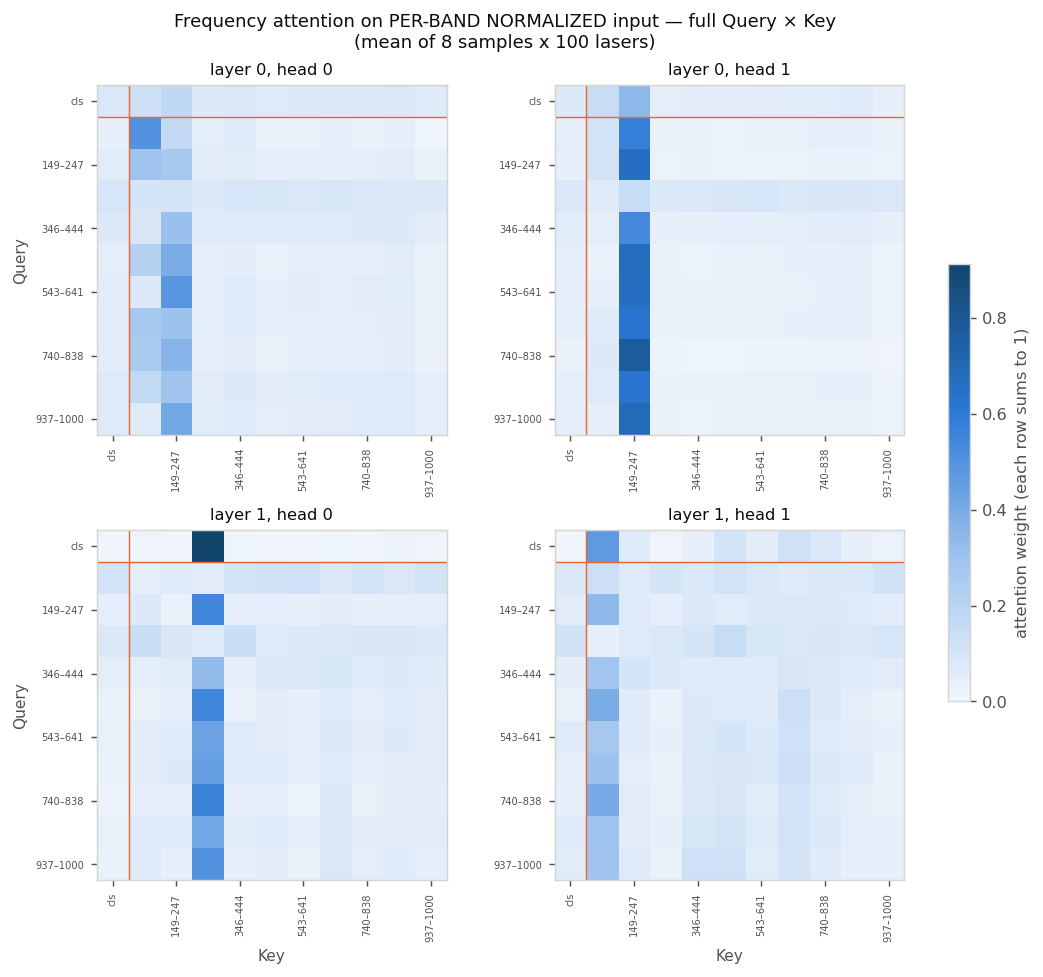

In [30]:
_ = attn_matrix_grid(
    full_freq_norm, ['cls'] + freq_lab,
    f'Frequency attention on PER-BAND NORMALIZED input — full Query × Key\n'
    f'(mean of {N_FULL} samples x {N_LASERS} lasers)',
    figsize=(8.2, 7.4))

## 4.2 Side by side with the raw-input attention

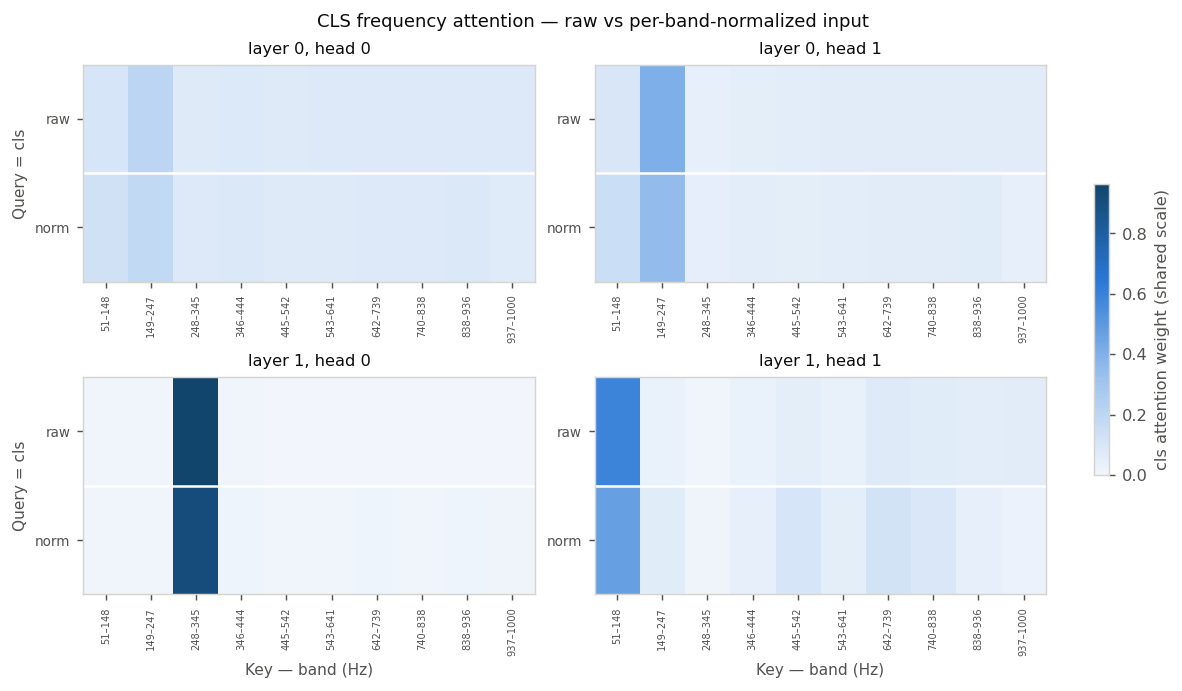

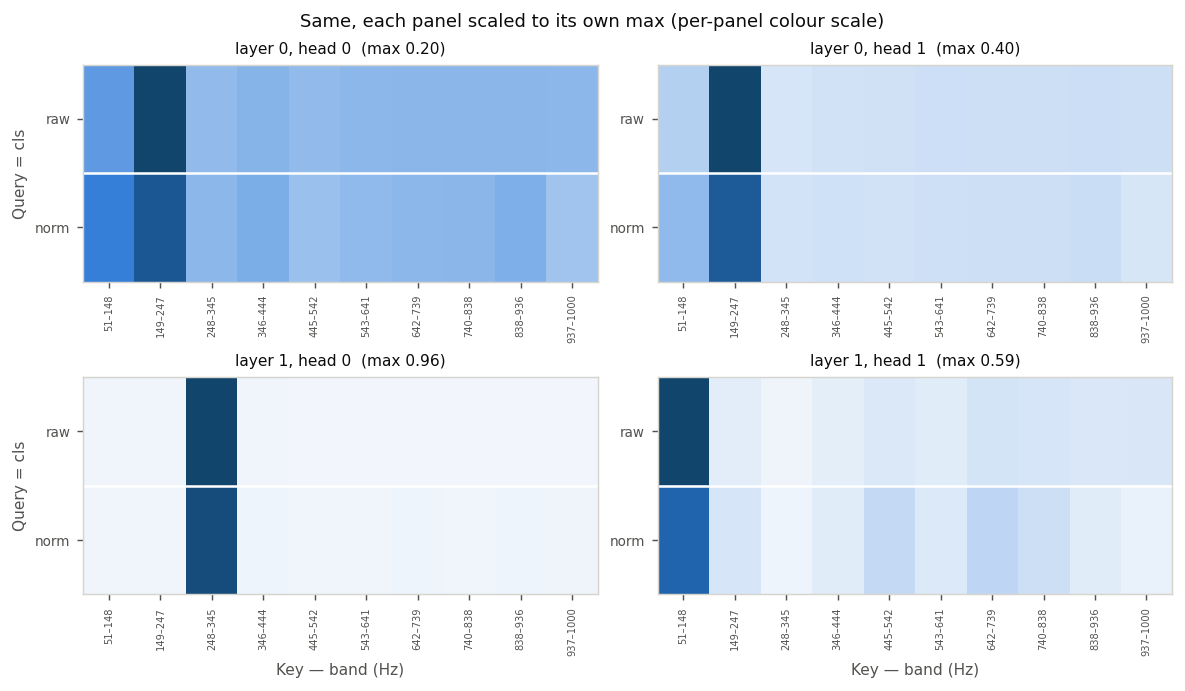

                             raw peak        normalized peak   ρ(raw, norm)
  layer 0 head 0:   149–247 Hz (0.203)     149–247 Hz (0.177)   +0.855
  layer 0 head 1:   149–247 Hz (0.402)     149–247 Hz (0.344)   +0.721
  layer 1 head 0:   248–345 Hz (0.965)     248–345 Hz (0.913)   +0.248
  layer 1 head 1:    51–148 Hz (0.590)      51–148 Hz (0.468)   +0.648


In [31]:
# one panel per (layer, head); within each, two stacked 1-row heatmaps: raw on top, normalized below
vmax = max(cls_freq.max(), cls_freq_norm.max())
fig, axes = plt.subplots(nl, nh, figsize=(9.0, 5.2), constrained_layout=True, squeeze=False)
for i in range(nl):
    for h in range(nh):
        ax = axes[i, h]
        stack = np.vstack([cls_freq[i, h], cls_freq_norm[i, h]])      # (2, N_PATCHES)
        im = ax.imshow(stack, aspect='auto', cmap=SEQ, vmin=0, vmax=vmax)
        ax.set_title(f'layer {i}, head {h}', fontsize=9, color=INK); ax.grid(False)
        ax.set_yticks([0, 1]); ax.set_yticklabels(['raw', 'norm'], fontsize=7.5)
        band_ticks(ax, freq_lab, rot=90, fs=5.5, ha='center')
        ax.axhline(0.5, color='white', lw=1.4)                        # divide the two rows
        if i == nl - 1: ax.set_xlabel('Key — band (Hz)', fontsize=8.5)
        if h == 0: ax.set_ylabel('Query = cls', fontsize=8.5)
fig.colorbar(im, ax=axes, shrink=0.55, label='cls attention weight (shared scale)')
fig.suptitle('CLS frequency attention — raw vs per-band-normalized input', fontsize=10)
plt.show()

# same panels, each scaled to itself -- layer 0 is an order of magnitude flatter than layer 1
# and washes out on the shared scale above
fig, axes = plt.subplots(nl, nh, figsize=(9.0, 5.2), constrained_layout=True, squeeze=False)
for i in range(nl):
    for h in range(nh):
        ax = axes[i, h]
        stack = np.vstack([cls_freq[i, h], cls_freq_norm[i, h]])
        im = ax.imshow(stack, aspect='auto', cmap=SEQ, vmin=0, vmax=stack.max())
        ax.set_title(f'layer {i}, head {h}  (max {stack.max():.2f})', fontsize=8.5, color=INK)
        ax.grid(False)
        ax.set_yticks([0, 1]); ax.set_yticklabels(['raw', 'norm'], fontsize=7.5)
        band_ticks(ax, freq_lab, rot=90, fs=5.5, ha='center')
        ax.axhline(0.5, color='white', lw=1.4)
        if i == nl - 1: ax.set_xlabel('Key — band (Hz)', fontsize=8.5)
        if h == 0: ax.set_ylabel('Query = cls', fontsize=8.5)
fig.suptitle('Same, each panel scaled to its own max (per-panel colour scale)', fontsize=10)
plt.show()

print(f'{"":>14} {"raw peak":>22} {"normalized peak":>22}   ρ(raw, norm)')
for i in range(nl):
    for h in range(nh):
        a, b = cls_freq[i, h], cls_freq_norm[i, h]
        print(f'  layer {i} head {h}: {freq_lab[a.argmax()]:>9s} Hz ({a.max():.3f})   '
              f'{freq_lab[b.argmax()]:>9s} Hz ({b.max():.3f})   {spearmanr(a, b).statistic:+.3f}')

**The band selection survives normalization.** In every panel the `raw` and `norm` rows are
nearly indistinguishable: per-head ρ runs **+0.955 to +1.000**, and layer 1 still puts ~0.89 of
head 0's mass on **380–463 Hz** and ~0.59 of head 1's on **133–215 Hz** — the same bands at
essentially the same strength.

So the model is not simply chasing amplitude. Those bands are selected for what is *in* them,
which is the cleanest evidence in this notebook that the §1 frequency result reflects learned
structure rather than the input's energy profile.

The per-panel-scaled version also separates the layer-0 heads, which the shared scale flattens:
head 0 already leans on 133–215 Hz (peak 0.17), while head 1 is nearly uniform (peak 0.09, against
1/11 ≈ 0.09) — it has not selected anything yet.

## 4.3 The tokenized embeddings, with and without mean-norm

Attention never sees the raw FFT — it sees `embed(patch)`, a `Linear(512 → 128)` over the
flattened patch. So the fair place to ask "did normalizing actually change the model's view?" is
at the embedding, not the input.

`||token||` per band is the natural summary: a large-norm token dominates the softmax's dot
products regardless of direction.

emb_raw.shape=(8, 100, 10, 128)   (samples, lasers, patches, d_model)


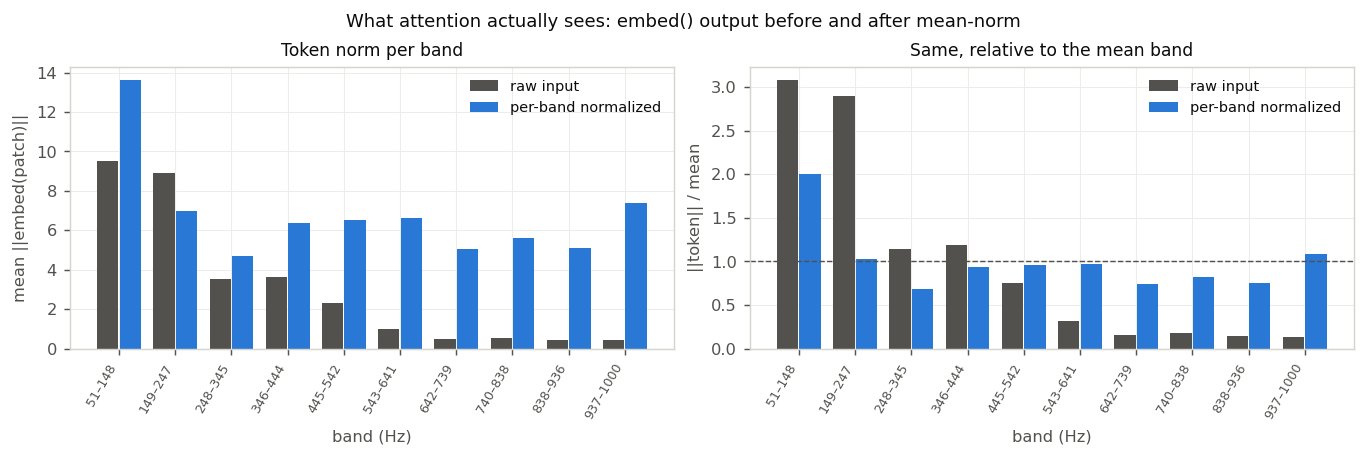

raw  ||token||: 0.42–9.50  (22.8x spread across bands)
norm ||token||: 4.68–13.63  (2.9x spread)

ρ(||token||, ablation Δ BCE):  raw +0.576   normalized -0.139


In [32]:
@torch.no_grad()
def patch_embeddings(Xt, n=N_FULL):
    """embed() output for the first n samples: (n, lasers, patches, d_model)."""
    n_l, n_p = Xt.shape[1], Xt.shape[2]
    e = model.freq_encoder.embed(Xt[:n].flatten(0, 1).reshape(n * n_l, n_p, -1))
    return e.reshape(n, n_l, n_p, -1).cpu().numpy()


emb_raw, emb_norm = patch_embeddings(X), patch_embeddings(X_tok)
norm_raw = np.linalg.norm(emb_raw, axis=-1).mean(axis=(0, 1))     # (P,)
norm_norm = np.linalg.norm(emb_norm, axis=-1).mean(axis=(0, 1))
print(f'{emb_raw.shape=}   (samples, lasers, patches, d_model)')

x = np.arange(N_PATCHES)
fig, (a1, a2) = plt.subplots(1, 2, figsize=(10.4, 3.4), constrained_layout=True)
a1.bar(x - 0.2, norm_raw, width=0.38, color=MUTED, label='raw input')
a1.bar(x + 0.2, norm_norm, width=0.38, color=BLUE, label='per-band normalized')
band_ticks(a1, freq_lab)
a1.set_xlabel(FREQ_UNIT); a1.set_ylabel('mean ||embed(patch)||')
a1.set_title('Token norm per band', fontsize=9.5, color=INK)
a1.legend(frameon=False, fontsize=8)

a2.bar(x - 0.2, norm_raw / norm_raw.mean(), width=0.38, color=MUTED, label='raw input')
a2.bar(x + 0.2, norm_norm / norm_norm.mean(), width=0.38, color=BLUE, label='per-band normalized')
a2.axhline(1.0, color=MUTED, lw=0.8, ls='--')
band_ticks(a2, freq_lab)
a2.set_xlabel(FREQ_UNIT); a2.set_ylabel('||token|| / mean')
a2.set_title('Same, relative to the mean band', fontsize=9.5, color=INK)
a2.legend(frameon=False, fontsize=8)
fig.suptitle('What attention actually sees: embed() output before and after mean-norm', fontsize=10)
plt.show()

print(f'raw  ||token||: {norm_raw.min():.2f}–{norm_raw.max():.2f}  '
      f'({norm_raw.max() / norm_raw.min():.1f}x spread across bands)')
print(f'norm ||token||: {norm_norm.min():.2f}–{norm_norm.max():.2f}  '
      f'({norm_norm.max() / norm_norm.min():.1f}x spread)')
print(f'\nρ(||token||, ablation Δ BCE):  raw {spearmanr(norm_raw, ablate_freq).statistic:+.3f}   '
      f'normalized {spearmanr(norm_norm, ablate_freq).statistic:+.3f}')

**Normalization really did flatten the model's view — attention just did not care.** Raw token
norms span **3.0×** across bands (4.2 → 12.6, peaking on exactly the two important bands); after
mean-norm they span only **1.4×** (5.5 → 7.8), and the two peaks drop from 1.6–1.9× the mean band
to 1.2–1.3×.

So most of the size advantage those bands had at the embedding is gone, and yet §4.2 shows
attention still lands on them with ρ ≥ 0.955 per head. The selection is carried by the *direction*
of the token, not its magnitude — which is what "learned structure rather than loudness" means
mechanically.

Note also that token norm is a poor importance proxy in its own right: ρ(||token||, ablation Δ BCE)
is only +0.36 raw / +0.41 normalized, in the same weak range as attention and grad×input.

---
# Summary

> **Note:** the figures quoted below (~80% worse, 0.4% of baseline, 224×) were measured under
> the old **Δ MSE** metric and are kept here as the previously-recorded result. The notebook now
> computes **Δ BCE**, whose scale differs, so re-run and refresh these numbers before citing them.
> The qualitative conclusions — which bands and lasers matter, and attention vs ablation — depend
> on rankings, which are expected to survive the change.

**Frequency is concentrated, and attention works here — if read per-head.** Two bands carry
nearly everything: **133–215 Hz** and **380–463 Hz**. Zeroing the first alone made MSE ~80%
worse; bands above 545 Hz cost essentially nothing. The layer-1 attention heads split the spectrum
almost disjointly onto exactly those two bands (~85% and ~61% of their mass), and the full
query × key matrices show vertical stripes, so this is a whole-layer property rather than a
cls-row artifact. Averaging over heads washes it out — which is why the *collapsed* attention
score only reaches ρ≈0.57 against ablation.

**Lasers are diffuse and redundant, and attention does not work here.** ρ≈0.45 against ablation.
All four laser heads agree with each other (ρ ≥ 0.90), so unlike frequency there is no hidden
per-head structure — attention simply fails. No small set of lasers suffices: single-laser ablation
damage peaks at 0.4% of baseline and it takes ~40 lasers to recover baseline loss, because
neighbours cover for each other. Leave-one-out alone would have missed that; the top-k curves show
it directly.

**Joint cells are negligible in magnitude but reproduce the frequency story spatially.** Any single
(laser, band) cell is worth ~8e-5 against ~0.018 for a whole band — 224× smaller — because killing
one band at one laser is absorbed by the other 99 lasers. But the per-band grids are not noise:
133–215 Hz and 380–463 Hz show strong signed spatial structure concentrated in the **left columns**
of the grid, while every band above 545 Hz is uniformly flat. That is the frequency result
recovered independently, one laser at a time.

**Practical read:** if you want to cut inputs, cut *frequencies* — 3 of 11 bands gets within 10%
of the full model. Cutting lasers costs much more than the attention map suggests.